In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import os
import matplotlib.patches as mpatches
import pyccl as ccl
from matplotlib.lines import Line2D
import gc
from matplotlib import cm
from scipy.optimize import curve_fit
from scipy.optimize import minimize

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Model using step-function HOD
## Define parameters

In [3]:
G_hi = 20.5
G_lo = 20.0

In [4]:
nthreads = 18

In [5]:
# cosmology 1
h=0.6844
Omega_m = 0.302

# cosmology 2
Omega_m_quaia = 0.343
h_quaia = 0.674

In [6]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

In [7]:
H0 = h*100 * u.km/u.s/u.Mpc
rbins_Mpc = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))

H0_quaia = h_quaia*100 * u.km/u.s/u.Mpc
rbins_Mpc_quaia = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0_quaia))

In [8]:
color1 = plt.get_cmap('Oranges')(np.linspace(0.333, 0.999, 2))[::-1]
color2 = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, 2))[::-1]

In [9]:
color3 = plt.get_cmap('Greys')(np.linspace(0.333, 0.999, 2))[::-1]

In [10]:
# Create the bins array
rpmin = 0.15 # 0.5 # 0.1 # start higher
rpmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rpbins = np.logspace(np.log10(rpmin), np.log10(rpmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

In [11]:
pimax = 80 # 40 # 5000.0 # 40.0

In [12]:
dpi = 0.01
pibins = np.arange(0, pimax+1, dpi)

In [13]:
z_bins = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
z_array = range(len(z_bins)-1)
mask = 0.5

In [14]:
Omega_c = 0.2513
Omega_b = 0.048
Omega_m_planck = Omega_c+Omega_b
cosmo = ccl.Cosmology(Omega_c=Omega_m*Omega_c/Omega_m_planck, Omega_b=Omega_m*Omega_b/Omega_m_planck,
                          h=h, n_s=0.95, sigma8=0.8)
cosmo_quaia = ccl.Cosmology(Omega_c=Omega_m_quaia*Omega_c/Omega_m_planck, Omega_b=Omega_m_quaia*Omega_b/Omega_m_planck,
                          h=h_quaia, n_s=0.95, sigma8=0.766)

In [15]:
cmap_qq = plt.get_cmap('Oranges')(np.linspace(0.333, 0.999, len(z_array)))
cmap_mm = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, len(z_array)))
cmap_b = plt.get_cmap('Greys')(np.linspace(0.333, 0.999, len(z_array)))
cmaps = [cmap_qq, cmap_mm]

In [16]:
orange = plt.get_cmap('Oranges')((0.333+0.999)/2)
green = plt.get_cmap('Greens')((0.333+0.999)/2)
grey = plt.get_cmap('Greys')((0.333+0.999)/2)
colors = [orange, green]

In [17]:
labels = ['Planck18', 'Quaia23']

In [18]:
h = 0.6774
Delta = 200
delta_c = 1.686

In [19]:
cosmo_default = ccl.Cosmology(Omega_b=0.0486, Omega_c=0.2589, h=h, n_s=0.9667, sigma8=0.8159)
hmf = ccl.halos.MassFuncTinker10()

In [20]:
NSIDE = 64
# fn_selhi = f"../data/maps/selection_function_NSIDE64_G20.5.fits"
# selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

## Define functions

In [21]:
def a_median(tab_datahi_mask_zbin0, key_zbin0 = ''):
    return 1/(1+np.median(tab_datahi_mask_zbin0['redshift_quaia'+key_zbin0]))

In [22]:
def b_qso(xi_qq, xi_mm, f):
    
    return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3

In [23]:
def nu(M, delta_c = delta_c, a = 1, cosmo = cosmo_default):
    
    sigma = cosmo.sigmaM(M/cosmo['h'], a = a)
   
    return delta_c/sigma

In [24]:
def n_g_theory(bins, n_total, a = 1, cosmo = cosmo_default, hmf = hmf, recenter = True):

    if recenter == True:
        bins = quaia.recenter(bins)
    nm = hmf(cosmo, bins/cosmo['h'], a)/cosmo['h']**3
    n_g = nm/(bins*np.log(10))*n_total
    n_g[np.isnan(n_g)]=0
    
    return n_g, nm

def bias(bins, n_m, a = 1, cosmo = cosmo_default, mod = False, recenter = True):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter)
    if recenter == True:
        bins = quaia.recenter(bins)
    n_g = np.trapz(n_g, bins)
    # dm = np.diff(bins) 
    dn_dm = nm/(bins*np.log(10))

    b1_E_tinker = b1_E_func(nu(bins, a = a, cosmo = cosmo), mod = mod)

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    return bias_function(n_g, integrand, b1_E_tinker, bins, recenter = recenter), n_g

In [25]:
def b1_E_func(nu, Delta = Delta, delta_c = delta_c, mod = False):

    delta_c = 1.686
    
    if mod == False:
        y = np.log10(Delta)
        A =  1.0+0.24*y*np.exp(-(4/y)**4)
        a = 0.44*y-0.88
        B = 0.183
        b =  1.5
        C = 0.019+0.107*y+0.19*np.exp(-(4/y)**4)
        c = 2.4
        
    else:
        A =  1.0
        a = 0.0906
        B = -4.5002
        b =  2.1419
        C = 4.9148
        c = 2.1419
        
    return 1-A*nu**a/(nu**a+delta_c**a)+B*nu**b+C*nu**c # Jose et al
    
def bias_function(n_g, integrand, b, bins, recenter = True):
    
    if recenter == True:
        bins = quaia.recenter(bins)
        
    return 1/n_g*np.trapz(integrand*b, bins)

In [26]:
def cf_2h(bins, n_m, a, cosmo, cf_matter, recenter = True):
    
    b_q, n_g = bias(bins, n_m, a, cosmo, recenter = recenter)
    return b_q**2*cf_matter, b_q

In [27]:
def M(bins, n_m, a = 1, cosmo = cosmo_default, mod = False, recenter = True):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter)
    if recenter == True:
        n_g = np.trapz(n_g, quaia.recenter(bins))
        dm = np.diff(bins) 
        dn_dm = nm/(quaia.recenter(bins)*np.log(10))
    else:
        n_g = np.trapz(n_g, bins)
        # dm = np.diff(bins) 
        dn_dm = nm/(bins*np.log(10))

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    if recenter == True:
        return bias_function(n_g, integrand, quaia.recenter(bins), bins, recenter = recenter), n_g
    else:
        return bias_function(n_g, integrand, bins, bins, recenter = recenter), n_g

In [28]:
def HOD(bins, M_min, fduty):

    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=M_min]=fduty

    return n_m

In [29]:
def n_DM(cosmo, a, M_min, hmf = hmf, M_max = 16.8, N = 79):
    
    bins = np.logspace(M_min, M_max, N)
    nm = hmf(cosmo, bins/cosmo['h'], a)/cosmo['h']**3 #/u.Mpc**3 # convert to 1/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.trapz(dn_dm, bins)

# Implement halo model
## Plot HOD: $\langle N(M) \rangle = \begin{cases}f_{duty} & M\geq M_{min} \\ 0 & M<M_{min}\end{cases}$
### At fixed $f_{duty}$ and $M_{min}$

In [30]:
# bins = np.logspace(9, 16.9, 50)
bins = np.logspace(9, 16.8, 79)
M_min = 12.8

In [31]:
M_min_array = [12.86, 12.74, 12.79, 12.82]

In [32]:
fduty = [0.018, 0.022, 0.056, 0.071]
n_m_array = []
for i in z_array:        
    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=10**M_min_array[i]]=fduty[i]
    n_m_array.append(n_m)

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_152916/2129638485.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), color = cmap_qq[i])
/tmp/ipykernel_152916/2129638485.py:7: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M (M_\odot)$')


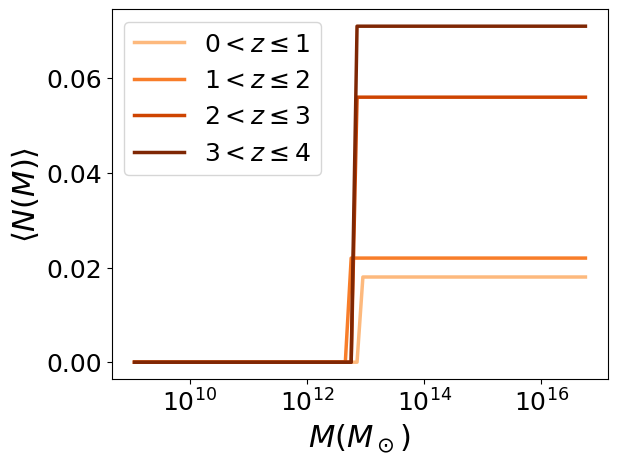

In [33]:
for i in z_array:
        
    plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), color = cmap_qq[i])

# plt.title('$M_{{min}}={:.2f} M_\odot$'.format(M_min))
plt.xscale('log')
plt.xlabel('$M (M_\odot)$')
plt.ylabel(r'$\langle N(M) \rangle$')
plt.legend()
plt.show()

### Now vary $M_{min}$

In [34]:
fduty = [0.018, 0.022, 0.056, 0.071]
n_m_array_2D = []
for i in z_array:

    n_m_array_2D.append([])
    
    for j in range(len(bins)):
        
        n_m=np.zeros(np.shape(quaia.recenter(bins)))
        n_m[quaia.recenter(bins)>=bins[j]]=fduty[i]
        n_m_array_2D[i].append(n_m)

<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_152916/4166141031.py:11: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(quaia.recenter(bins), n_m_array_2D[i][j*k], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), color = cmap_qq[i],
/tmp/ipykernel_152916/4166141031.py:14: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.0f}<z \leq{:.0f}: f_{{duty}}={:.2f}\%$'.format(i, i+1, fduty[i]*100))
/tmp/ipykernel_152916/4166141031.py:19: SyntaxWarning: invalid escape sequence '\o'
  ax1.set_xlabel('$M (M_\odot)$')


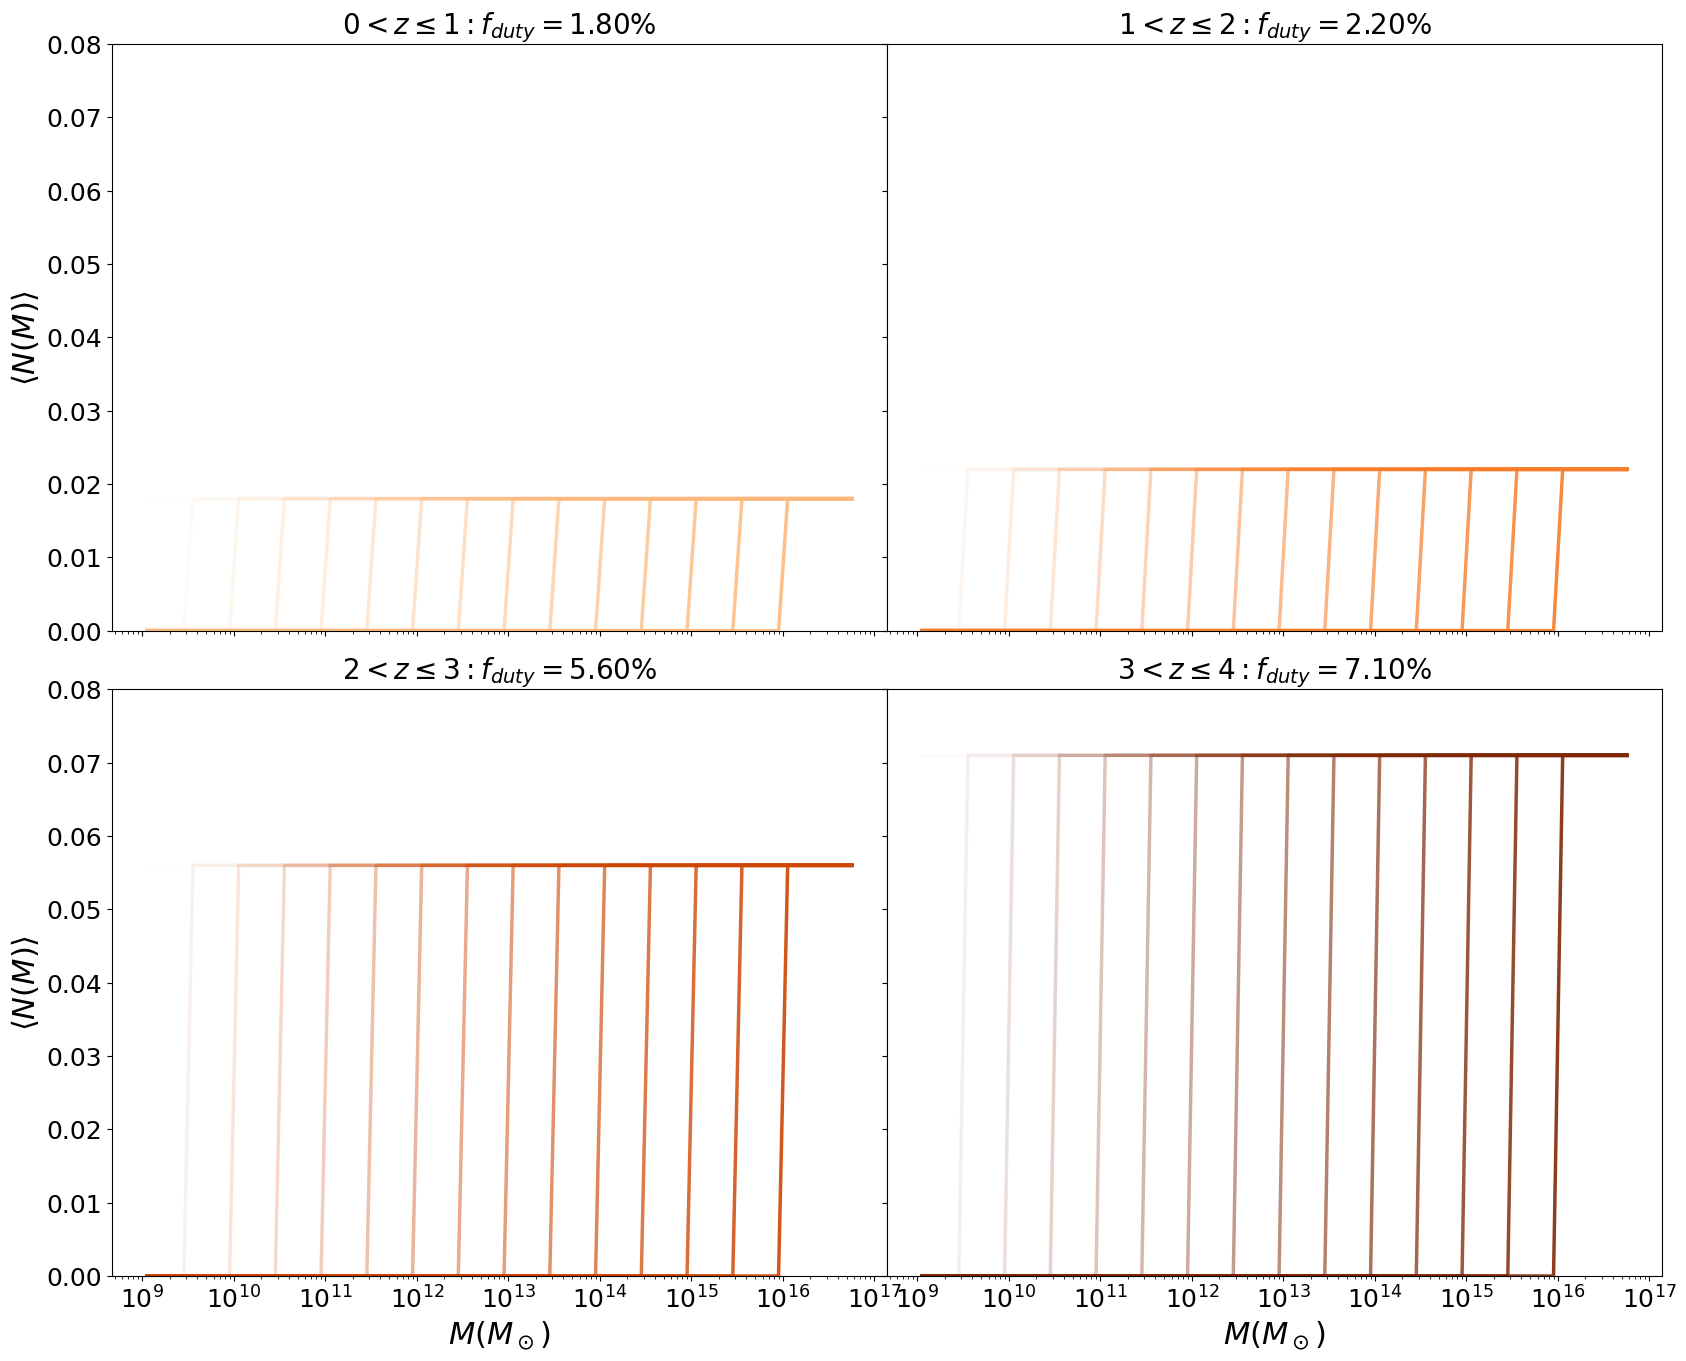

In [35]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)
k = 5

for i in z_array:

    ax1 = fig.add_subplot(gs[i])

    for j in range(int(len(bins)/k)):
        
        ax1.plot(quaia.recenter(bins), n_m_array_2D[i][j*k], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), color = cmap_qq[i], 
                 alpha = (j*k+1)/len(bins))

    ax1.set_title('${:.0f}<z \leq{:.0f}: f_{{duty}}={:.2f}\%$'.format(i, i+1, fduty[i]*100))
    ax1.set_xscale('log')
    ax1.set_ylim(0, 0.08)

    if i>1:
        ax1.set_xlabel('$M (M_\odot)$')
    else:
        ax1.set_xticklabels([])
    if i%2 == 0:
        ax1.set_ylabel(r'$\langle N(M) \rangle$')
    else:
        ax1.set_yticklabels([])

plt.show()

### And vary $f_{duty}$

In [36]:
fduty_array = np.logspace(-5,0, 51) #-4
n_m_array_3D = []
for i in z_array:

    n_m_array_3D.append([])
    
    for j in range(len(bins)):
        
        n_m_array_3D[i].append([])
        
        for k in range(len(fduty_array)):
        
            n_m=np.zeros(np.shape(quaia.recenter(bins)))
            n_m[quaia.recenter(bins)>=bins[j]]=fduty_array[k]
            n_m_array_3D[i][j].append(n_m)

<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\o'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_152916/2192279323.py:14: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(quaia.recenter(bins), n_m_array_3D[i][j*k][f[i]], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1),
/tmp/ipykernel_152916/2192279323.py:17: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.0f}<z \leq{:.0f}: f_{{duty}}={:.2f}\%$'.format(i, i+1, fduty_array[f[i]]*100))
/tmp/ipykernel_152916/2192279323.py:24: SyntaxWarning: invalid escape sequence '\o'
  ax1.set_xlabel('$M (M_\odot)$')


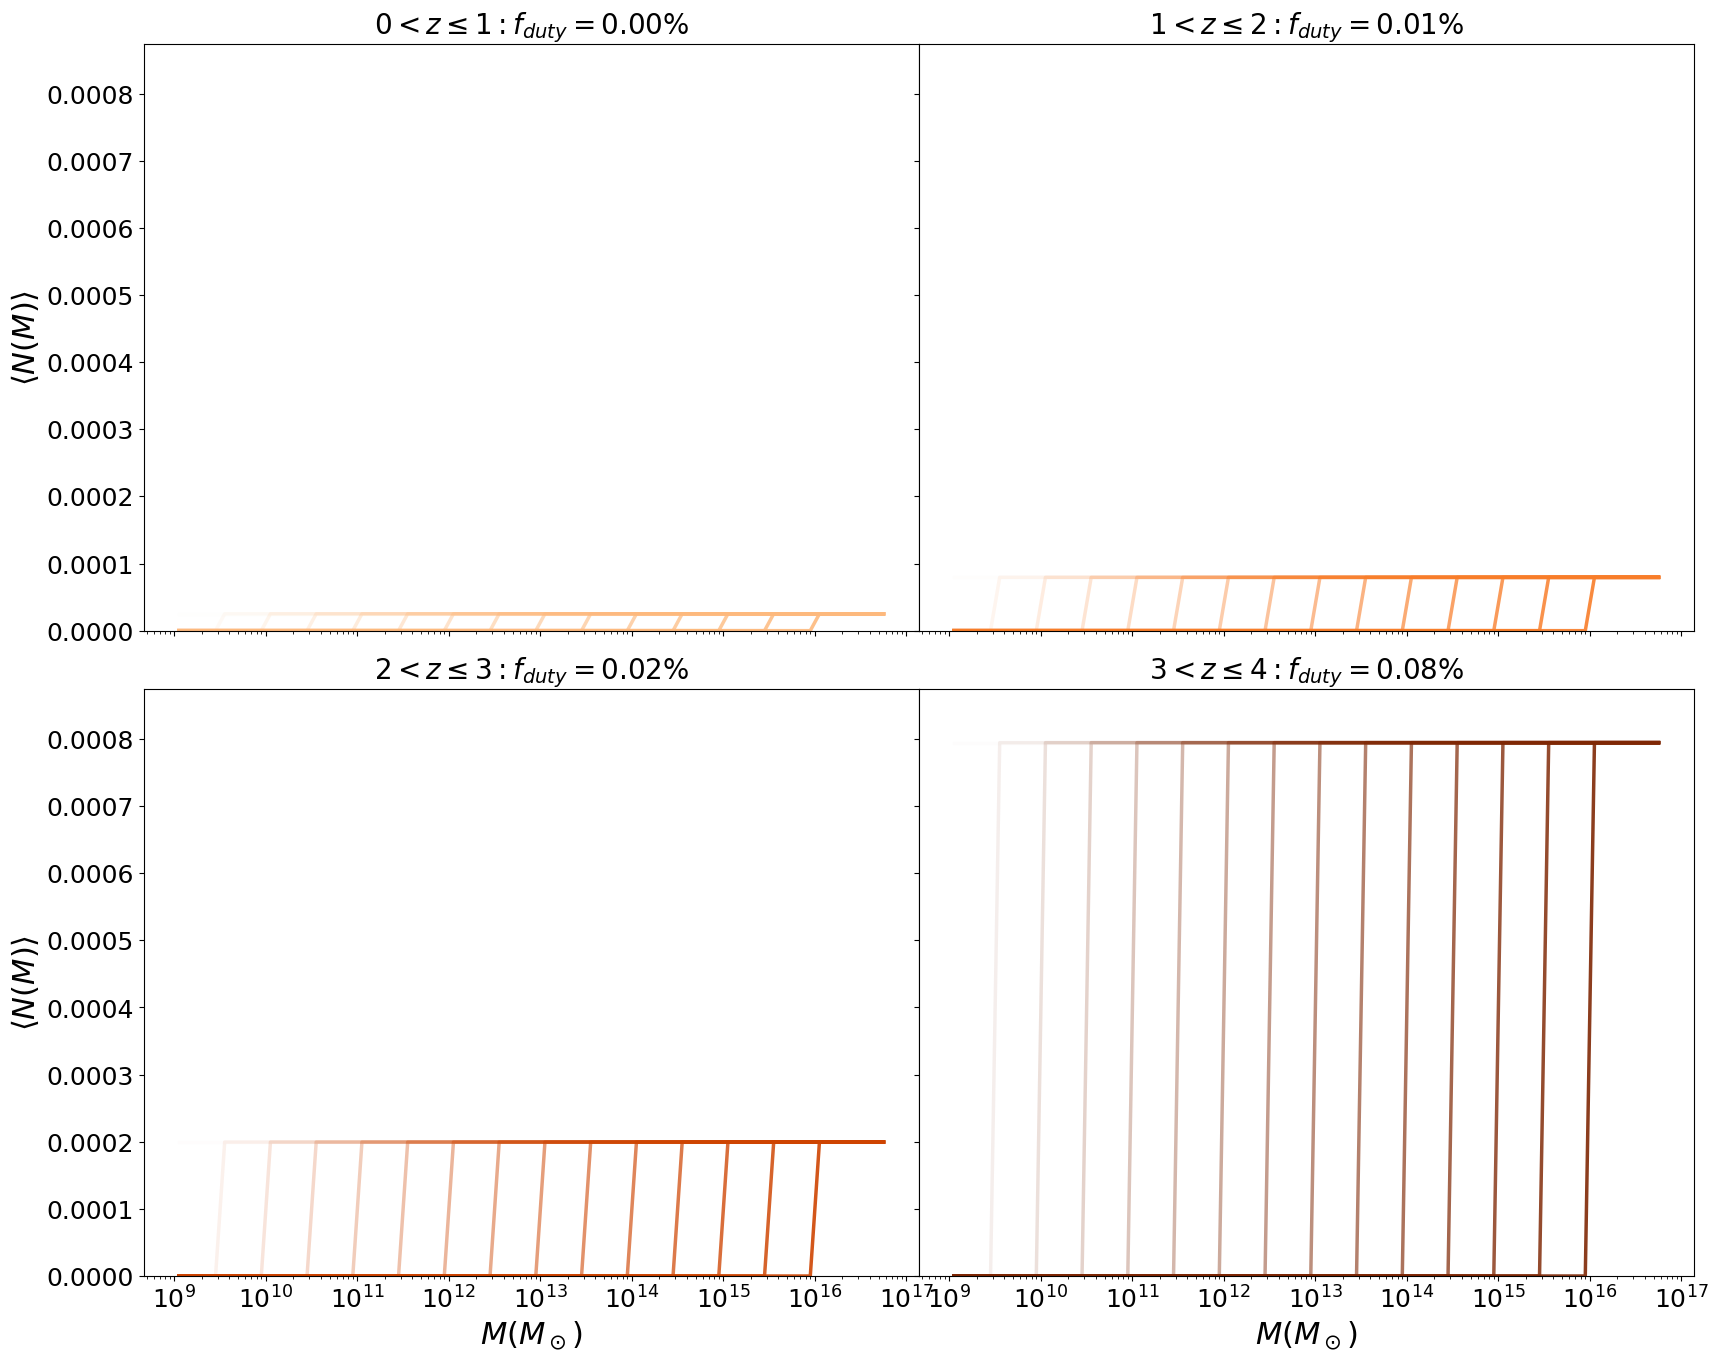

In [37]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)
k = 5
# f = np.sort(np.random.randint(0, len(fduty_array), size = len(z_array)))
rng = np.random.default_rng()
f = np.sort(rng.choice(len(fduty_array), size = len(z_array), replace = False))

for i in z_array:

    ax1 = fig.add_subplot(gs[i])
    
    for j in range(int(len(bins)/k)):
        
        ax1.plot(quaia.recenter(bins), n_m_array_3D[i][j*k][f[i]], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), 
                 color = cmap_qq[i], alpha = (j*k+1)/len(bins))

    ax1.set_title('${:.0f}<z \leq{:.0f}: f_{{duty}}={:.2f}\%$'.format(i, i+1, fduty_array[f[i]]*100))
    # ax1.set_title('${:.0f}<z \leq{:.0f}: \log_{{10}}(f_{{duty}})={:.2f}$'.format(i, i+1, np.log10(fduty_array[f[i]])))
    # ax1.set_title('${:.0f}<z \leq{:.0f}: f_{{duty}}={:.2e}$'.format(i, i+1, fduty_array[f[i]]))
    ax1.set_xscale('log')
    ax1.set_ylim(0, 1.1*np.max(fduty_array[f]))

    if i>1:
        ax1.set_xlabel('$M (M_\odot)$')
    else:
        ax1.set_xticklabels([])
    if i%2 == 0:
        ax1.set_ylabel(r'$\langle N(M) \rangle$')
    else:
        ax1.set_yticklabels([])

plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_152916/3038851972.py:12: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(quaia.recenter(bins), n_m_array_3D[i][l][j*k], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), color = cmap_qq[i],
/tmp/ipykernel_152916/3038851972.py:15: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.0f}<z \leq{:.0f}: M_{{min}}={:.2f} M_{{\odot}}$'.format(i, i+1, np.log10(bins[l])))
/tmp/ipykernel_152916/3038851972.py:20: SyntaxWarning: invalid escape sequence '\o'
  ax1.set_xlabel('$M (M_\odot)$')


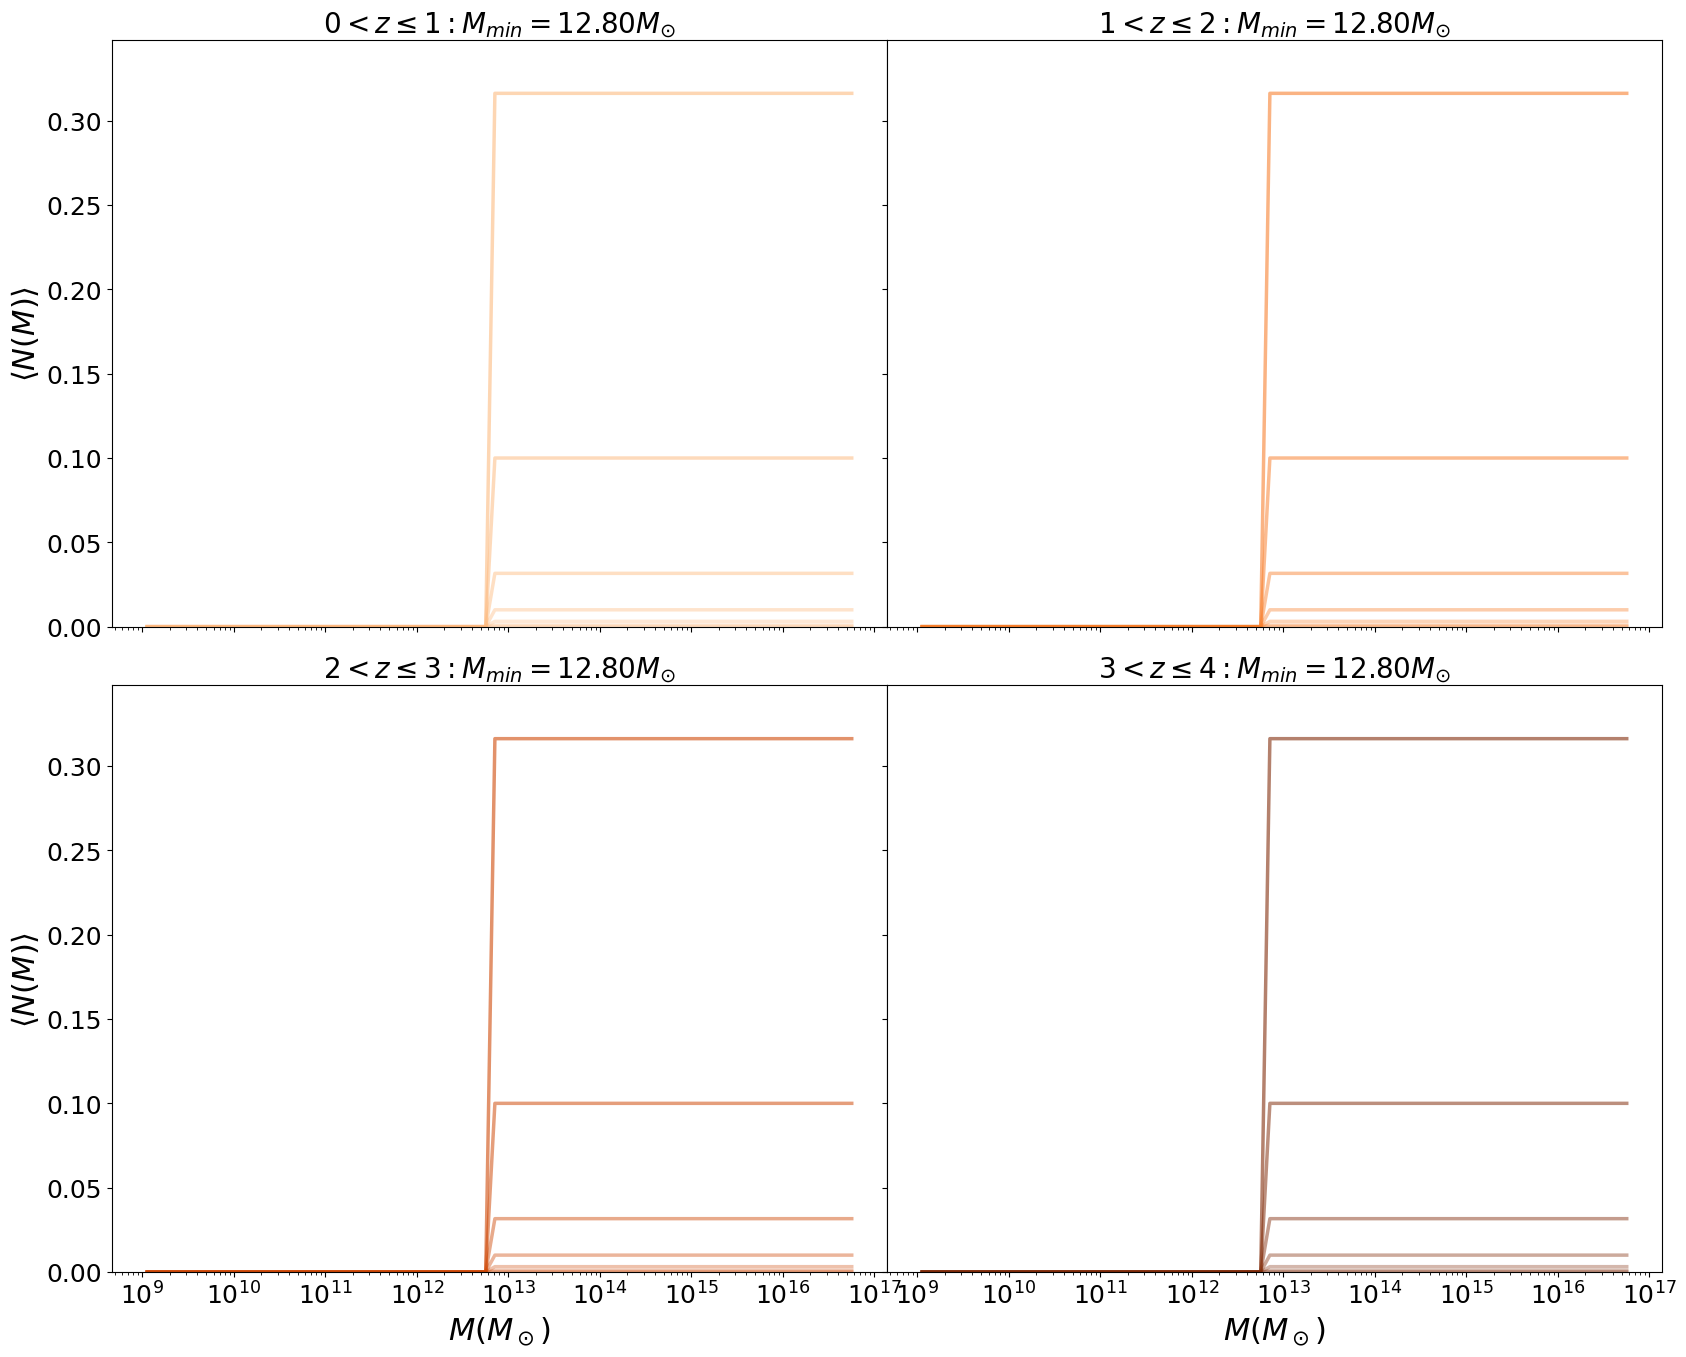

In [38]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)
k = 5
l = 38 # 25

for i in z_array:

    ax1 = fig.add_subplot(gs[i])
    
    for j in range(int(len(fduty_array)/k)):
        
        ax1.plot(quaia.recenter(bins), n_m_array_3D[i][l][j*k], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), color = cmap_qq[i], 
                 alpha = (j*k+1)/len(bins))

    ax1.set_title('${:.0f}<z \leq{:.0f}: M_{{min}}={:.2f} M_{{\odot}}$'.format(i, i+1, np.log10(bins[l])))
    ax1.set_xscale('log')
    ax1.set_ylim(0, 1.1*fduty_array[j*k])

    if i>1:
        ax1.set_xlabel('$M (M_\odot)$')
    else:
        ax1.set_xticklabels([])
    if i%2 == 0:
        ax1.set_ylabel(r'$\langle N(M) \rangle$')
    else:
        ax1.set_yticklabels([])

plt.show()

## Calculate $b_{\mathrm{qq}}(s,z)=\sqrt{\frac{\xi^{(s)}_{\mathrm{qq}}(s)}{\xi^{(r)}_\mathrm{mm}(r)}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$
### Use a 50th percentile mask

In [39]:
Omega_m_array = [Omega_m, Omega_m_quaia]
h_array = [h, h_quaia]
cosmos = [cosmo, cosmo_quaia]
linestyles = ['-', '--']

cf_zbin_percentile, cf_matter_zbin_percentile = {label: [] for label in labels}, {label: [] for label in labels}
yerr_cf, b_cf = {label: [] for label in labels}, {label: [] for label in labels}
a_zbin, b_cf_q = {label: [] for label in labels}, {label: [] for label in labels}
i = 1
    
for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _ = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)

    # quasar correlation function
    cf, qq, qr = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
               rbins = rbins, Om0 = Omega_m_array[i], h = h_array[i], error = True)
    cf_zbin_percentile[labels[i]].append(cf)

    # scale factor
    a = a_median(tab_datahi_mask_zbin0)
    a_zbin[labels[i]].append(a)

    # matter correlation function
    H0 = h_array[i]*100 * u.km/u.s/u.Mpc
    rbins_Mpc = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
    cf_matter = ccl.correlations.correlation_3d(cosmos[i], r=rbins_Mpc, a=a)
    cf_matter_zbin_percentile[labels[i]].append(cf_matter)

    # effective bias 
    b = np.sqrt(cf/cf_matter)
    b_cf[labels[i]].append(b)

    # yerr
    yerr=(1+cf)/np.sqrt(qq)
    yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
    yerr_cf[labels[i]].append(yerr)

    # qso bias
    b_cf_q[labels[i]].append(b_qso(cf, cf_matter, ccl.growth_rate(cosmos[i], a)))

G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336


[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_152916/1428743751.py:34: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_152916/1428743751.py:38: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_152916/1428743751.py:39: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
/tmp/ipykernel_152916/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


G20.5_zmin1.0zmax2.0: 0.28              467913 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_152916/1428743751.py:34: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_152916/1428743751.py:38: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_152916/1428743751.py:39: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
/tmp/ipykernel_152916/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_152916/1428743751.py:34: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_152916/1428743751.py:38: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_152916/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


G20.5_zmin3.0zmax4.0: 0.21              28061 vs 35630


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_152916/1428743751.py:34: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_152916/1428743751.py:38: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_152916/1428743751.py:39: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
/tmp/ipykernel_152916/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


## Measure $\xi(s)$ and calculate the two-halo term: $\xi_{2 h}(r) \approx\left[n_q^{-1} \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle b_h(M)\right]^2 \xi_m(r)$
###  Implement Poisson error bars: $\Delta \xi(s)=\begin{cases}\frac{1+\xi(s)}{\sqrt{DD(s)}} & \xi(s)\geq 0 \\ \sqrt{\frac{1+\xi(s)_\mathrm{model}}{D R}} & \xi(s)<0\end{cases}$ 

In [40]:
b_eff_cf20 = np.load('../results/b_eff_cf20.npy')
b_eff_wp20 = np.load('../results/b_eff_wp20.npy')

In [41]:
bins_M_min = np.logspace(M_min, 16.8, 79)

In [42]:
fduty = [0.018, 0.022, 0.056, 0.071]
n_m_array, bins_M_min = [], []
for i in z_array:   
    # n_m=np.zeros(np.shape(quaia.recenter(bins)))
    # n_m[quaia.recenter(bins)>=10**M_min_array[i]]=fduty[i]
    bins_i = np.logspace(M_min_array[i], 16.8, 79)
    n_m=np.ones(np.shape(bins_i))*fduty[i]
    n_m_array.append(n_m)
    bins_M_min.append(bins_i)

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_152916/1018944775.py:21: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[labels[i]][j])


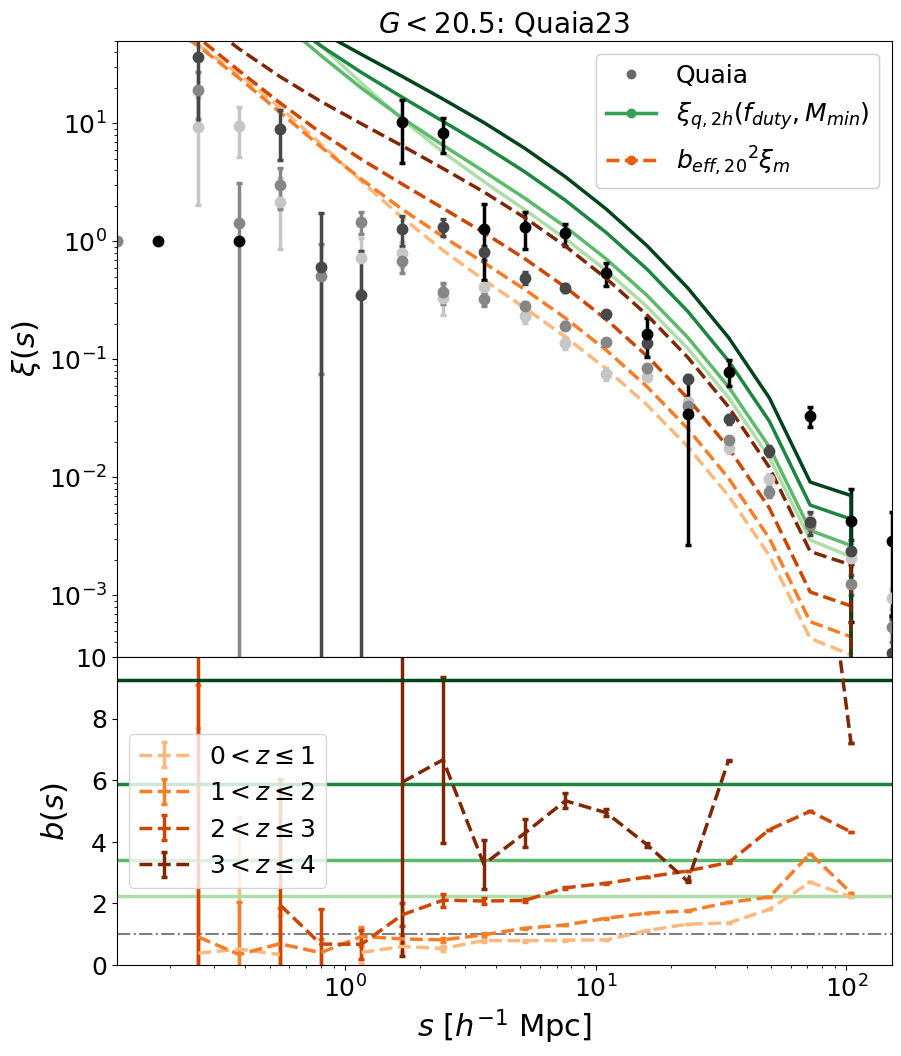

In [43]:
fig = plt.figure(figsize = (10, 12))
gs = gridspec.GridSpec(2, 1, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', r'$\xi_{2h}$']
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

i = 1
for j in z_array:

    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_b[j], 
                 yerr = yerr_cf[labels[i]][j], linestyle = 'none', markeredgewidth = 2.5, capsize = 2.5) #  markerfacecolor = 'white'
    cf_2h_zbin, b_q = cf_2h(bins_M_min[j], n_m_array[j], a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j], recenter = False)
    ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, label = r'\xi_2h}',
             color = cmap_mm[j], linestyle = '-')
    ax1.plot(quaia.recenter(rbins), b_eff_cf20[j]**2*cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, linestyle = '--',
             label = r'$b_{20}$ model', color = cmap_qq[j])

    ax2.errorbar(quaia.recenter(rbins), b_cf[labels[i]][j], linewidth = 2.5, capsize = 2.5, markeredgewidth = 2.5, linestyle = '--',
                 label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[labels[i]][j])
    ax2.axhline(b_q, linewidth = 2.5, color = cmaps[i][j])
    
ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax1.set_xticklabels([])
ax1.set_ylim(3e-4, 5e1)

custom_lines = [Line2D([0], [0], color = grey, marker = 'o', linestyle = 'none', linewidth = 2.5),
                Line2D([0], [0], color = green, marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = orange, marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, ['Quaia', r'$\xi_{q,2h}(f_{duty}, M_{min})$', r'${b_{eff, 20}}^2\xi_m$'], loc = 'upper right')
ax1.add_artist(second_legend)

ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
ax2.axhline(1, linestyle = '-.', color = 'black', zorder = 0, alpha = 0.5)
ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax2.set_ylim(0, 10)
ax2.legend()

ax1.set_ylabel(r'$\xi(s)$')
ax2.set_ylabel(r'$b(s)$')

if scale == 'log':
    ax1.set_xscale('log')
    ax2.set_xscale('log')

plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_152916/1118833463.py:19: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[labels[i]][j])
/tmp/ipykernel_152916/1118833463.py:23: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))


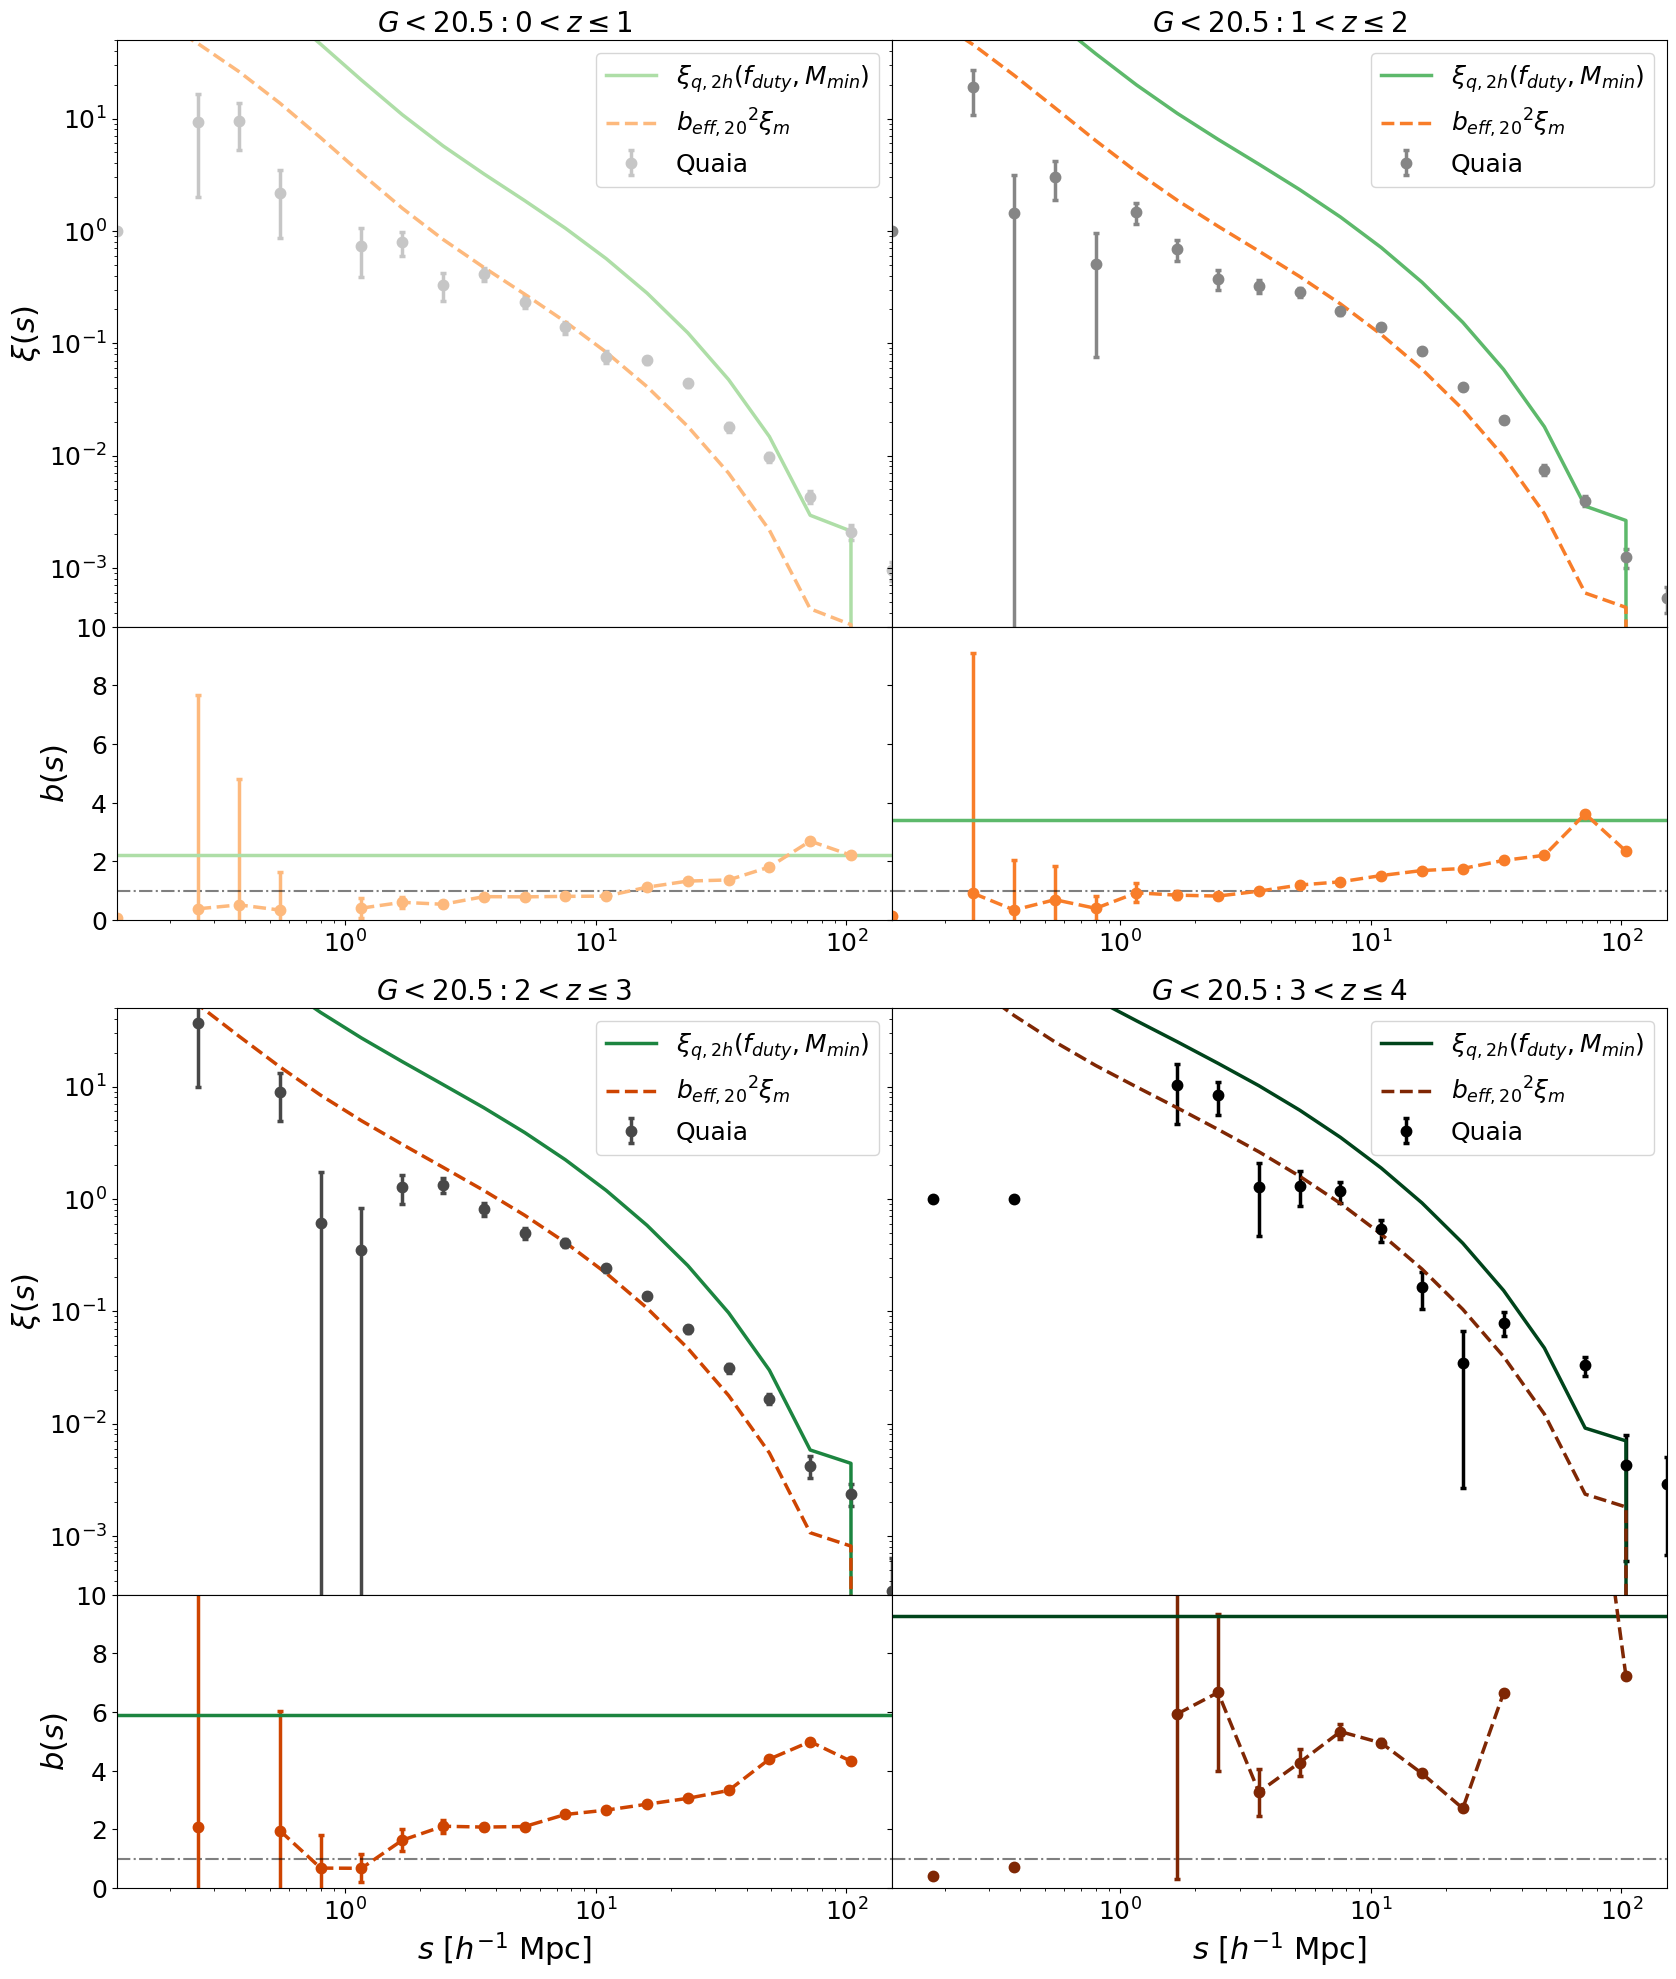

In [44]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.15, 1, 0.5], hspace = 0, wspace = 0)

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
            
    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = cmap_b[j],
                yerr = yerr_cf[labels[i]][j], markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    cf_2h_zbin, b_q = cf_2h(bins_M_min[j], n_m_array[j], a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j], recenter = False)
    ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, label = r'$\xi_{q,2h}(f_{duty}, M_{min})$',
             color = cmaps[i][j])
    ax1.plot(quaia.recenter(rbins), b_eff_cf20[j]**2*cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5,
             label = r'${b_{eff, 20}}^2\xi_m$', color = cmap_qq[j], linestyle = '--')

    ax2.errorbar(quaia.recenter(rbins), b_cf[labels[i]][j], linewidth = 2.5, marker = 'o', linestyle = '--', markeredgewidth = 2.5, capsize = 2.5,
                 label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[labels[i]][j])
    ax2.axhline(b_q, linewidth = 2.5, color = cmaps[i][j])

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)
    ax1.legend()

    ax2.axhline(1, linestyle = '-.', color = 'black', alpha = 0.5)
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 10)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    # else:
    # if k != 0:
    # ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

### Vary $M_{min}$

In [45]:
n_m_array_2D = []
for i in z_array:

    n_m_array_2D.append([])
    
    for j in range(len(bins)):
        
        # bins_j = np.logspace(np.log10(bins[j]), 16.8, 79)
        
        # n_m=np.zeros(np.shape(quaia.recenter(bins)))
        # n_m[quaia.recenter(bins)>=bins[j]]=fduty[i]
        n_m=np.ones(np.shape(bins))*fduty[i]
        n_m_array_2D[i].append(n_m)
        # bins_M_min_array.append(bins_j)

In [46]:
bins_M_min_array = [np.logspace(np.log10(bins[j]), 16.8, 79) for j in range(len(bins))]

<>:26: SyntaxWarning: invalid escape sequence '\l'
<>:26: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_152916/2122983457.py:26: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[labels[i]][j])
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


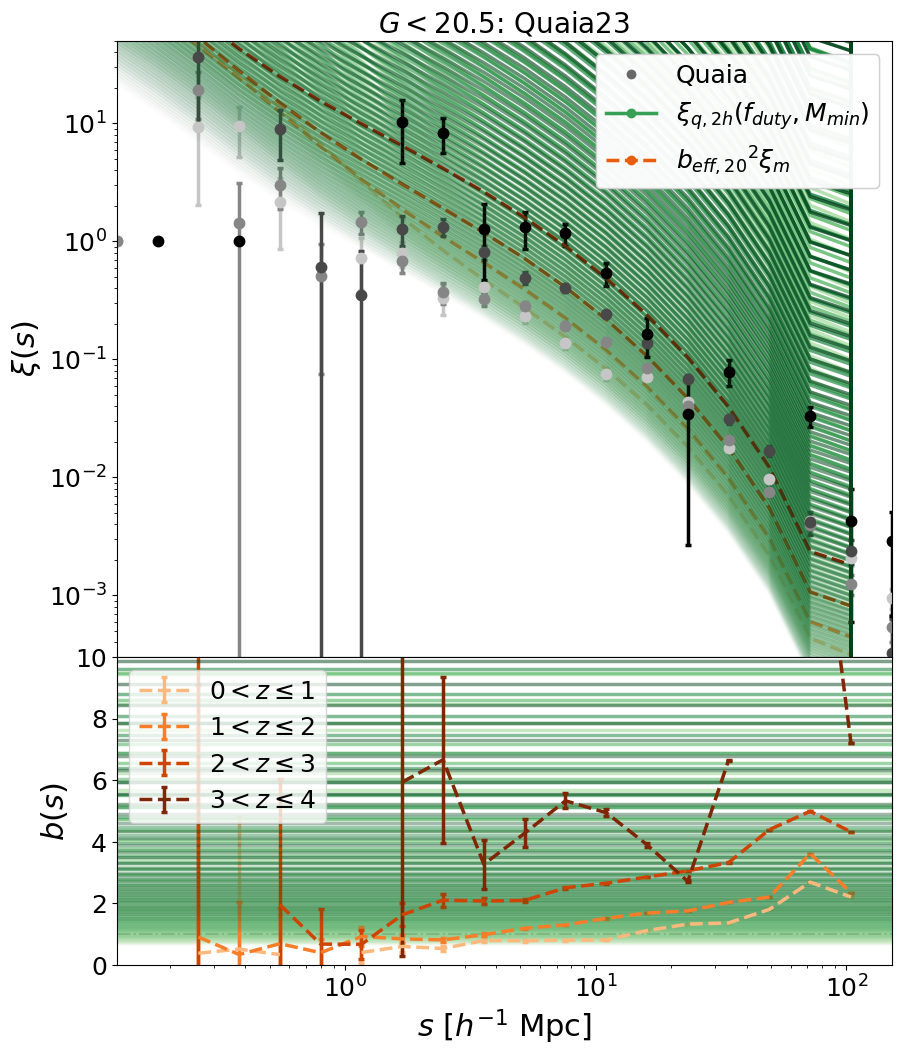

In [47]:
fig = plt.figure(figsize = (10, 12))
gs = gridspec.GridSpec(2, 1, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', r'$\xi_{2h}$']
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

i = 1
for j in z_array:

    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_b[j], 
                 yerr = yerr_cf[labels[i]][j], linestyle = 'none', markeredgewidth = 2.5, capsize = 2.5) #  markerfacecolor = 'white'
    ax1.plot(quaia.recenter(rbins), b_eff_cf20[j]**2*cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, linestyle = '--',
             label = r'$b_{20}$ model', color = cmap_qq[j])
    
    for k in range(len(bins)):
        
        cf_2h_zbin, b_q = cf_2h(bins_M_min_array[k], n_m_array_2D[j][k], a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j],
                                recenter = False)
        ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, label = r'\xi_2h}',
             color = cmap_mm[j], linestyle = '-', alpha = (k+1)/len(bins))
        ax2.axhline(b_q, linewidth = 2.5, color = cmaps[i][j],  alpha = (k+1)/len(bins))

    ax2.errorbar(quaia.recenter(rbins), b_cf[labels[i]][j], linewidth = 2.5, capsize = 2.5, markeredgewidth = 2.5, linestyle = '--',
                 label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[labels[i]][j])
    
ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax1.set_xticklabels([])
ax1.set_ylim(3e-4, 5e1)

custom_lines = [Line2D([0], [0], color = grey, marker = 'o', linestyle = 'none', linewidth = 2.5),
                Line2D([0], [0], color = green, marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = orange, marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, ['Quaia', r'$\xi_{q,2h}(f_{duty}, M_{min})$', r'${b_{eff, 20}}^2\xi_m$'], loc = 'upper right')
ax1.add_artist(second_legend)

ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
ax2.axhline(1, linestyle = '-.', color = 'black', zorder = 0, alpha = 0.5)
ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax2.set_ylim(0, 10)
ax2.legend()

ax1.set_ylabel(r'$\xi(s)$')
ax2.set_ylabel(r'$b(s)$')

if scale == 'log':
    ax1.set_xscale('log')
    ax2.set_xscale('log')

plt.show()

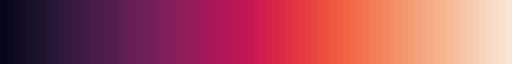

In [48]:
cmap = sns.color_palette("rocket", n_colors = len(bins))
palette = matplotlib.colors.ListedColormap(cmap)
palette

<>:73: SyntaxWarning: invalid escape sequence '\o'
<>:73: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_152916/1478906062.py:73: SyntaxWarning: invalid escape sequence '\o'
  cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: d

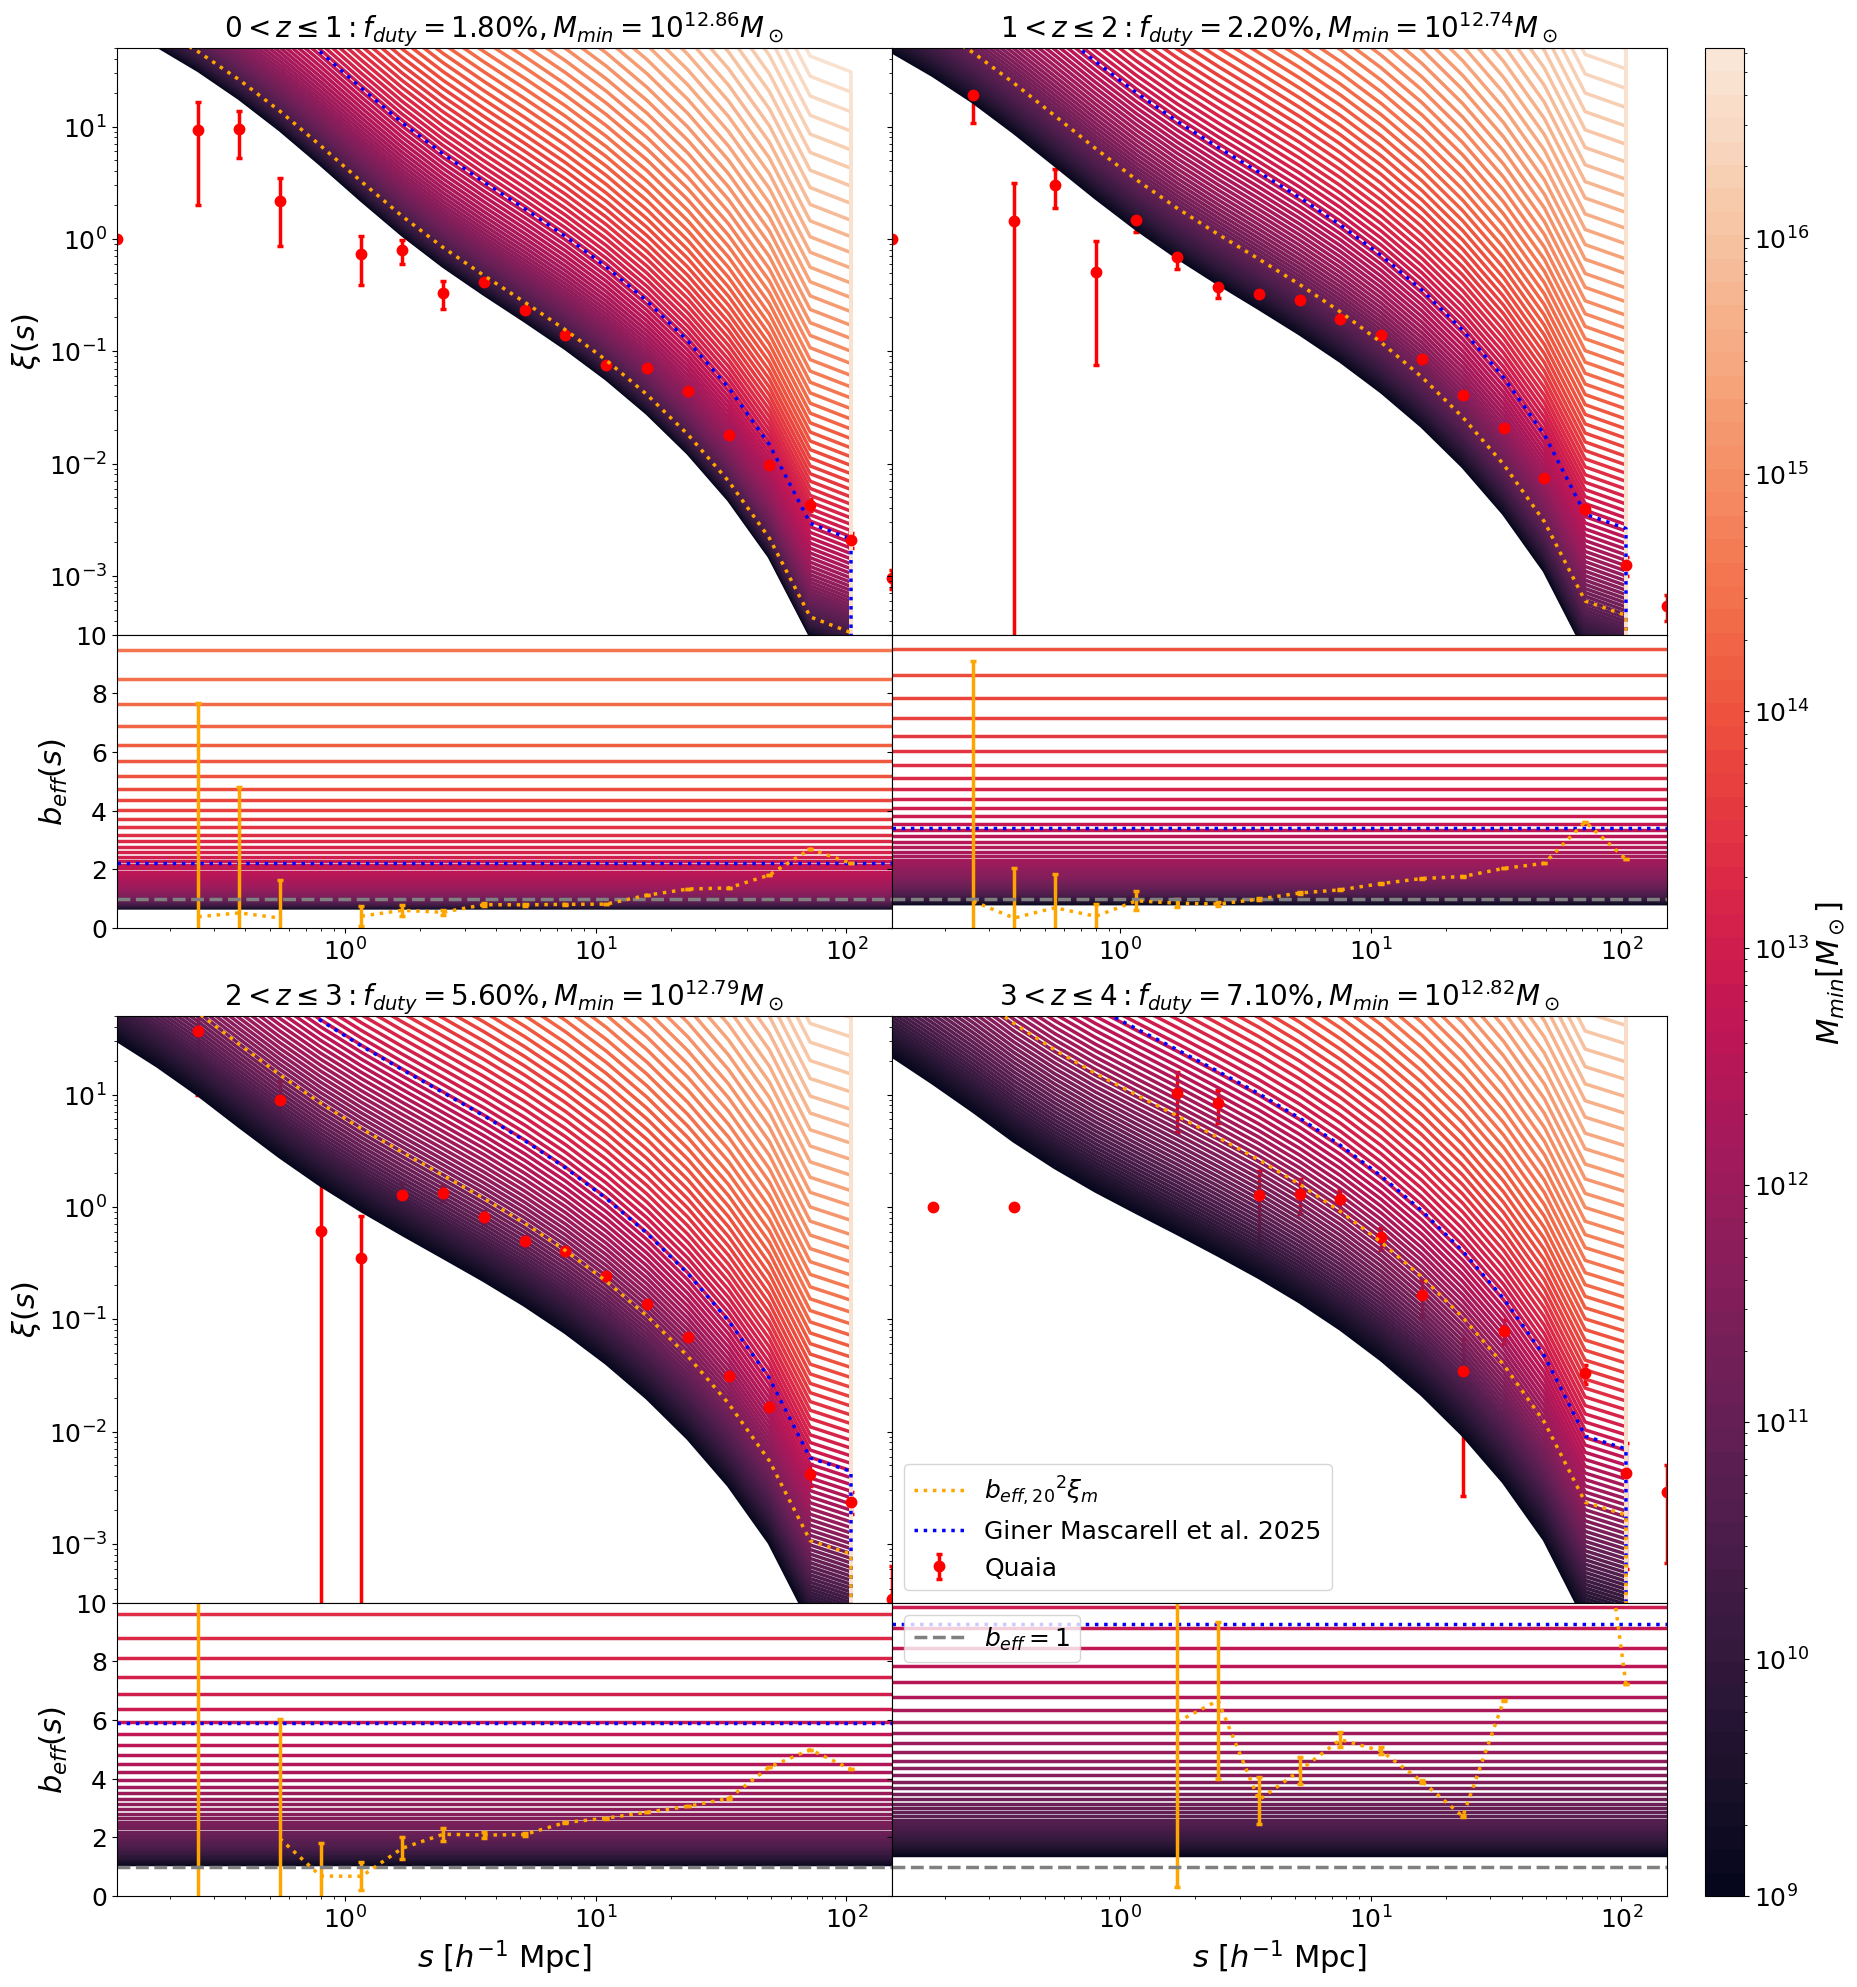

In [49]:
fig = plt.figure(figsize = (21, 24))
gs = gridspec.GridSpec(5, 4, height_ratios = [1, 0.5, 0.15, 1, 0.5], width_ratios = [1, 1, 0.05, 0.05], hspace = 0, wspace = 0)
ax1_idx = [0, 1, 12, 13]
ax2_idx = [4, 5, 16, 17]
k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[ax1_idx[j]])
    ax2 = fig.add_subplot(gs[ax2_idx[j]])
            
    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red', 
                yerr = yerr_cf[labels[i]][j], markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')    #color = cmap_b[j],
    ax1.plot(quaia.recenter(rbins), b_eff_cf20[j]**2*cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5,
             label = r'${b_{eff, 20}}^2\xi_m$', color = 'orange', linestyle = ':', zorder = 3)

    for l in range(len(bins)):

        # print(np.log10(bins[l]), (l+1)/len(bins))
        cf_2h_zbin, b_q = cf_2h(bins_M_min_array[l], n_m_array_2D[j][l], a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j], 
                                recenter = False)
        ax1.plot(quaia.recenter(rbins), cf_2h_zbin, color = cmap[l], linewidth = 2.5)
             # color = cmaps[i][j], alpha = (l+1)/len(bins))
        ax2.axhline(b_q, color = cmap[l], linewidth = 2.5) # color = cmaps[i][j], alpha = (l+1)/len(bins))
        
    cf_2h_zbin, b_q = cf_2h(bins_M_min[j], n_m_array[j], a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j], recenter = False)
    ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, color = 'blue', label = "Giner Mascarell et al. 2025", linestyle = ':')
             # label = '$\log_{{10}}(M_{{min}}/M_\odot) = {:.2f}$'.format(M_min), linestyle = ':')
    ax2.axhline(b_q, linewidth = 2.5, color = 'blue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

    ax2.errorbar(quaia.recenter(rbins), b_cf[labels[i]][j], linewidth = 2.5, linestyle = ':', markeredgewidth = 2.5, capsize = 2.5,
                 color = 'orange', yerr = yerr_cf[labels[i]][j])

    if (j + k) % 6 < 2:
        ax1.set_title(r'${:.0f}<z \leq{:.0f}: f_{{duty}}={:.2f}\%, M_{{min}}=10^{{{:.2f}}} M_\odot$'.format(j, j+1, fduty[j]*100, M_min_array[j]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)

    ax2.axhline(1, linestyle = '--', color = 'grey', linewidth = 2.5, label = '$b_{eff}=1$')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 10)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b_{eff}(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    # else:
    #     ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

# custom_lines = [Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'none', linewidth = 2.5),
#                 # Line2D([0], [0], color = 'orange', marker = 'o', linestyle = '-', linewidth = 2.5), 
#                 Line2D([0], [0], color = 'orange', marker = 'o', linestyle = '--', linewidth = 2.5)]
# second_legend = ax1.legend(custom_lines, ['Quaia', r'${b_{eff, 20}}^2\xi_m$'], loc = 'upper right') # r'$\xi_{q,2h}(f_{duty}, M_{min})$', 
# ax1.add_artist(second_legend)

ax1.legend()
ax2.legend()

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

# Calculate derived parameters
## Plot b(z)

In [50]:
def b_eboss(z):
    
    return 0.278*((1+z)**2-6.565) + 2.393

def b_quaia(b_0, a, cosmo = cosmo_quaia):
    
    return b_0/ccl.growth_factor(cosmo, a)

In [51]:
b_cf20 = np.load('../results/b_cf20.npy')
b_wp20 = np.load('../results/b_wp20.npy')

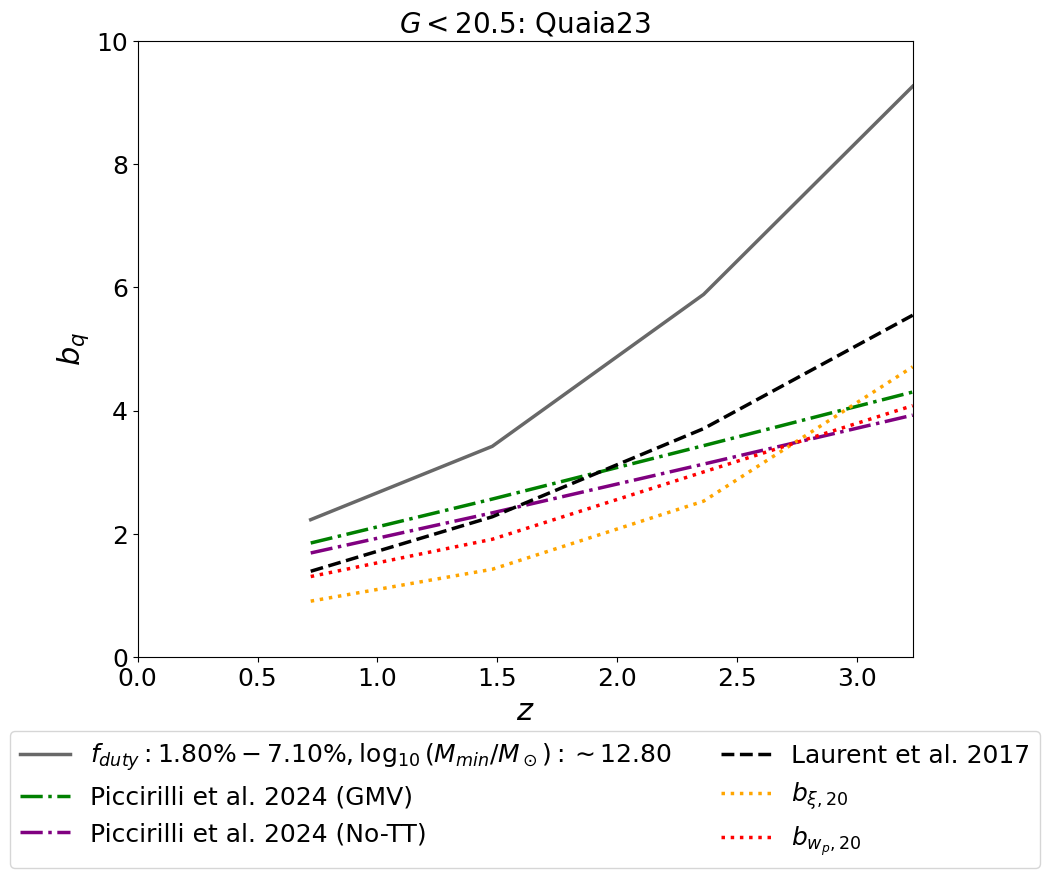

In [52]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
i = 1

b_q = [cf_2h(bins_M_min[j], n_m_array[j], a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j], 
             recenter = False)[1] for j in z_array]
zbin = 1/np.array(a_zbin[labels[i]])-1
plt.plot(zbin, b_q, linewidth = 2.5, color = grey,
         label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, \log_{{10}}(M_{{min}}/M_\odot):\sim{:.2f}$'.format(fduty[0]*100, fduty[-1]*100, M_min))
plt.plot(zbin, b_quaia(1.26, a_zbin[labels[i]]), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
plt.plot(zbin, b_quaia(1.15, a_zbin[labels[i]]), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
plt.plot(zbin, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
         color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761

plt.plot(zbin, b_cf20, linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
plt.plot(zbin, b_wp20, linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

plt.title('$G<{}$: {}'.format(G_hi, labels[i]))

plt.xlabel('$z$')
plt.ylim(0, 10)
plt.xlim(0, zbin[-1])
plt.ylabel(r'$b_q$')
plt.legend(ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')

plt.show()

### Vary $M_{min}$

<>:47: SyntaxWarning: invalid escape sequence '\o'
<>:47: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_152916/2780356956.py:47: SyntaxWarning: invalid escape sequence '\o'
  cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


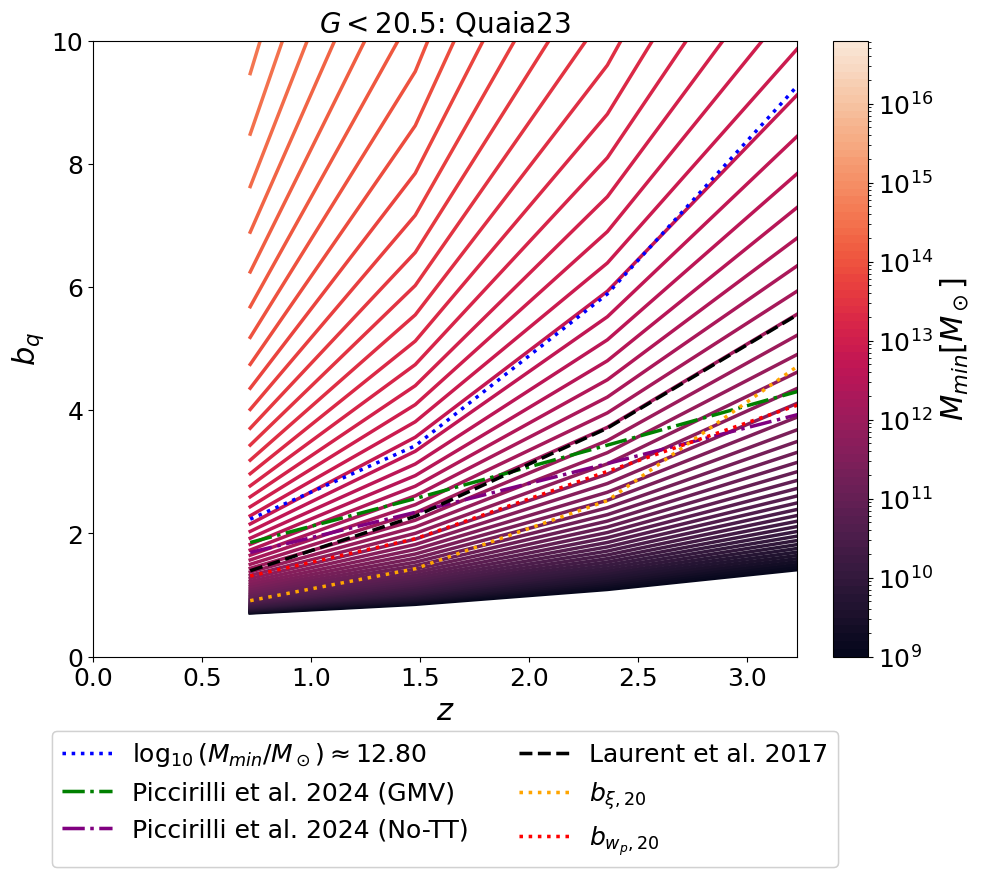

In [53]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])

for k in range(len(bins)):
    
    b_q = [cf_2h(bins_M_min_array[k], n_m_array_2D[j][k], a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j],
                 recenter = False)[1] for j in z_array]
    zbin = 1/np.array(a_zbin[labels[i]])-1
    ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap[k]) #grey,
             # label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])), alpha = (1+k)/len(bins))
    
b_q = [cf_2h(bins_M_min[j], n_m_array[j], a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j],
             recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'blue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
ax1.plot(zbin, b_quaia(1.26, a_zbin[labels[i]]), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_quaia(1.15, a_zbin[labels[i]]), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
         color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761

ax1.plot(zbin, b_cf20, linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
ax1.plot(zbin, b_wp20, linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

ax1.set_xlabel('$z$')
ax1.set_ylim(0, 10)
ax1.set_xlim(0, zbin[-1])
ax1.set_ylabel(r'$b_q$')
# plt.legend(ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')

custom_lines = [Line2D([0], [0], color = 'blue', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx {:.2f}$'.format(M_min), 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 'Laurent et al. 2017',
                                          r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
fig.add_artist(second_legend)

# cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.BoundaryNorm(np.log10(bins), palette.N)), cax = fig.add_subplot(gs[:,-1]), label = '$\log_{10}(M_{min}/M_\odot)$')
cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
# cbar.set_label('$\log_{10}(M_{min}/M_\odot)$')
plt.show()

## Calculate halo mass as $\langle M \rangle \approx n_q^{-1} \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle M$

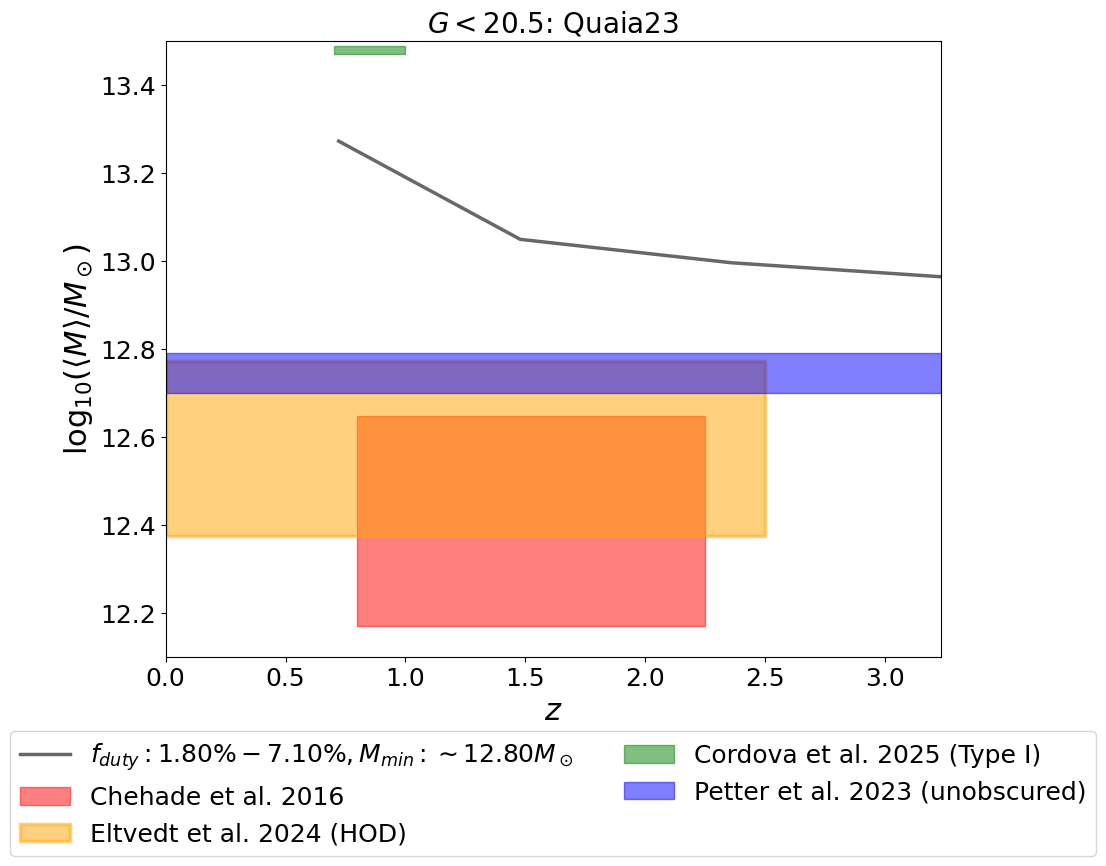

In [54]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
i = 1

M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[0] for j in z_array]
plt.plot(zbin, np.log10(M_h), linewidth = 2.5, 
         label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:\sim{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, M_min), color = grey)
z = np.linspace(0.8, 2.25)
plt.fill_between(z, [np.log10(1e12/cosmo_quaia['h'])]*len(z), [np.log10(3e12/cosmo_quaia['h'])]*len(z), alpha = 0.5, label = 'Chehade et al. 2016', 
                 color = 'red')
plt.title('$G<{}$: {}'.format(G_hi, labels[i]))
plt.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/cosmo_quaia['h'])]*len(z), [np.log10(4e12/cosmo_quaia['h'])]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
plt.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
plt.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/cosmo_quaia['h'])]*len(z), [np.log10(10**12.62/cosmo_quaia['h'])]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
ax1.add_artist(second_legend)

plt.xlabel('$z$')
plt.ylim(12.1, 13.5)
plt.legend(ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
plt.ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
plt.xlim(0, zbin[-1])
plt.show()

### Vary $M_{min}$

<>:48: SyntaxWarning: invalid escape sequence '\o'
<>:48: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_152916/1333251151.py:48: SyntaxWarning: invalid escape sequence '\o'
  cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


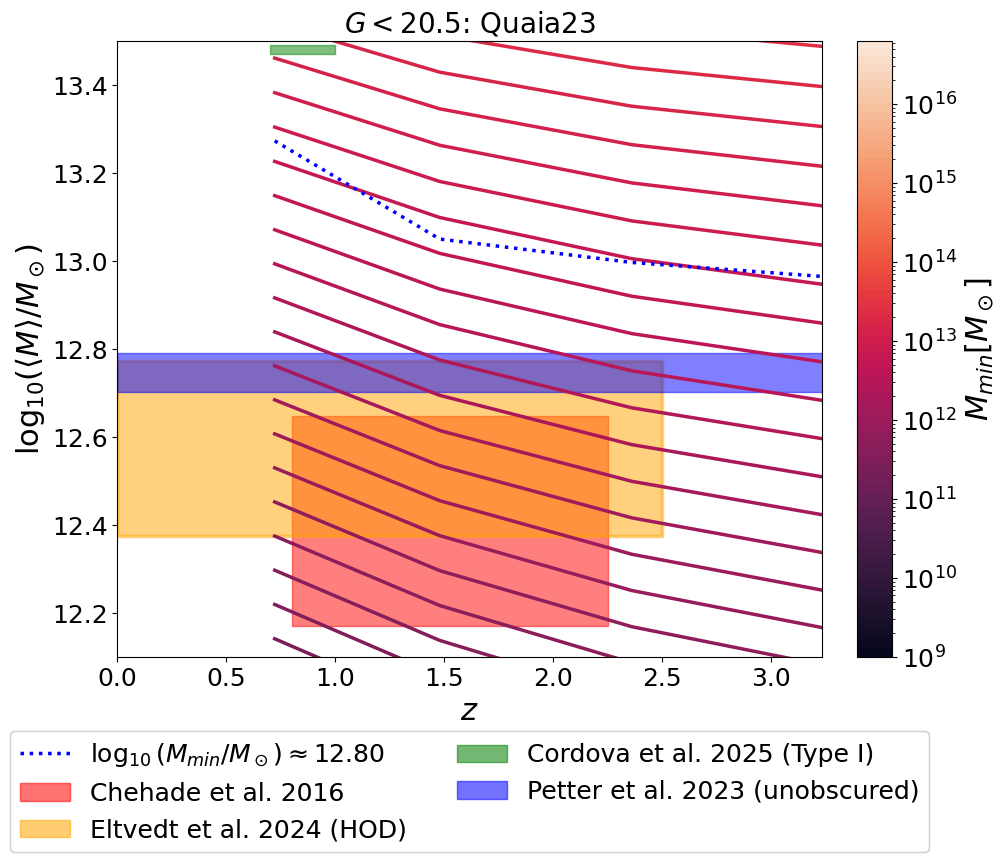

In [55]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
i = 1

for k in range(len(bins)):
    
    M_h = [M(bins_M_min_array[k], n_m_array_2D[j][k], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[0] for j in z_array]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, 
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
             color = cmap[k]) #, alpha = (1+k)/len(bins))
M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'blue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
z = np.linspace(0.8, 2.25)
ax1.fill_between(z, [np.log10(1e12/cosmo_quaia['h'])]*len(z), [np.log10(3e12/cosmo_quaia['h'])]*len(z), alpha = 0.5, label = 'Chehade et al. 2016', 
                 color = 'red')
ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/cosmo_quaia['h'])]*len(z), [np.log10(4e12/cosmo_quaia['h'])]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/cosmo_quaia['h'])]*len(z), [np.log10(10**12.62/cosmo_quaia['h'])]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = 'blue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min),
                           # [r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:[{:.2f}-{:.2f}] M_\odot$'.format(fduty[0]*100, fduty[-1]*100, 
                                                                                                          # np.log10(bins[0]), np.log10(bins[-1])), 
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
fig.add_artist(second_legend)

# patch = [mpatches.Patch(color=cmaps[l][j], label = labels[l]) for l in range(len(labels))]
# first_legend = ax1.legend(handles=patch, loc = 'lower left')
# ax1.add_artist(first_legend)

ax1.set_xlabel('$z$')
# plt.legend(ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(0, zbin[-1])
ax1.set_ylim(12.1, 13.5)

# cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.BoundaryNorm(np.log10(bins), palette.N)), cax = fig.add_subplot(gs[:,-1]), label = '$\log_{10}(M_{min}/M_\odot)$')
cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

## Calculate number density as $n_q \approx \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle$

In [56]:
tab_datahi_mask_zbins, selfunc_hi_bins = [], []
for j in z_array:
    
    tab_datahi_mask_zbin0, _, _, _, _, _, selfunc_hi_bin0 = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)
    tab_datahi_mask_zbins.append(tab_datahi_mask_zbin0['redshift_quaia'])
    selfunc_hi_bins.append(selfunc_hi_bin0)

G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336
G20.5_zmin1.0zmax2.0: 0.28              467913 vs 648196
G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508
G20.5_zmin3.0zmax4.0: 0.21              28061 vs 35630


In [57]:
n_q, n_q_err = [], []

for j in z_array:
    
    N = len(tab_datahi_mask_zbins[j])
    # r = quaia.comoving_dist(tab_datahi_mask_zbins[j], h = cosmo_quaia['h'], Om0 = cosmo_quaia['Omega_b']+cosmo_quaia['Omega_c']).value # Mpc/h
    cp = np.percentile(selfunc_hi_bins[j], mask*100)
    f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[j][selfunc_hi_bins[j]>=cp]*hp.nside2pixarea(NSIDE))
    print(f_sky)
    # V = f_sky*(4/3*np.pi*(np.max(r)**3-np.min(r)**3)) #*cosmo_quaia['h']**3 # convert to 1/Mpc^3
    zmax = quaia.comoving_dist(j+1, h = cosmo_quaia['h'], Om0 = cosmo_quaia['Omega_b']+cosmo_quaia['Omega_c']).value
    zmin = quaia.comoving_dist(j, h = cosmo_quaia['h'], Om0 = cosmo_quaia['Omega_b']+cosmo_quaia['Omega_c']).value
    V = f_sky*(4/3*np.pi*(zmax**3-zmin**3)) #*cosmo_quaia['h']**3 # convert to 1/Mpc^3
    
    n_q.append(N/V)
    n_q_err.append(np.sqrt(N)/V) # Poisson error

0.29746390823822866
0.3229221159273539
0.2744938755620083
0.2551523073813655


### Test method against Storey-Fisher et al. 2023

In [58]:
tab_datahi_mask_zbin0, _, _, _, _, _, selfunc_hi_bin0 = quaia.make_bins(G_hi, [0], True, ['z'], 
                                                                                     bins = [None], tab_gcat_type = 'data',
                                                                                     method = [None], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)

Leaving tab_gcat_catalog unbinned
G20.5: 0.28              938957 vs 1295502


In [59]:
# cp = np.percentile(selfunc_hi_bin0, mask*100)
cp = 0
f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bin0[selfunc_hi_bin0>=cp]*hp.nside2pixarea(NSIDE))
print(f_sky)

0.4789816662703589


### Check against $V_{eff}$

In [60]:
cosmo_planck20 = ccl.Cosmology(Omega_c=0.265, Omega_b=0.049, h=h, n_s=0.95, sigma8=0.8)

In [61]:
r = quaia.comoving_dist(tab_datahi_mask_zbin0['redshift_quaia'], h = cosmo_planck20['h'], 
                        Om0 = cosmo_planck20['Omega_b']+cosmo_planck20['Omega_c'])
r = quaia.comoving_dist(tab_datahi_mask_zbin0['redshift_quaia'], h = cosmo_planck20['h'], 
                        Om0 = cosmo_planck20['Omega_b']+cosmo_planck20['Omega_c'])
V = f_sky*(4/3*np.pi*(np.max(r)**3-np.min(r)**3))
V.to((u.Gpc/cu.littleh)**3) # i guess we expect a different result since kate said she calculated it differently?

<Quantity 285.81871708 Gpc3 / littleh3>

### Test method against Giner Mascarell et al. 2025

In [62]:
tab_datahi_mask_zbins, selfunc_hi_bins = [], []
b = [0, 0, 0, 30]
for j in z_array:
    
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, selfunc_hi_bin0_mask_inv, _, selfunc_hi_bin0 = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                                                               mask_type = 'b', 
                                                                                                                               b = b[j],
                                                                                             bins = [z_bins], tab_gcat_type = 'data',
                                                                                             method = ['minmax'], fac_rand = 25,
                                                                                             n_bins = [None])
    tab_datahi_mask_zbins.append(tab_datahi_mask_zbin0['redshift_quaia'])
    selfunc_hi_bins.append(selfunc_hi_bin0)

G20.5_zmin0.0zmax1.0: 0.00              324336 vs 324336
G20.5_zmin1.0zmax2.0: 0.00              648196 vs 648196
G20.5_zmin2.0zmax3.0: 0.00              286508 vs 286508
G20.5_zmin3.0zmax4.0: 0.23              27584 vs 35630


In [63]:
n_q_b, n_q_b_err = np.array([])/V.unit, np.array([])/V.unit

for j in z_array:
    
    N = len(tab_datahi_mask_zbins[j])
    # r = quaia.comoving_dist(tab_datahi_mask_zbins[j], h = cosmo_planck20['h'], Om0 = cosmo_planck20['Omega_b']+cosmo_planck20['Omega_c']) #Mpc/h
    ra, dec = hp.pix2ang(NSIDE, range(len(selfunc_hi_bins[j])), lonlat = True)
    c = SkyCoord(ra=ra*u.degree, dec=dec*u.degree)
    mask_datahi_bin0 = np.abs(c.galactic.b.value)>=b[j]
    f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[j][mask_datahi_bin0]*hp.nside2pixarea(NSIDE))
    print(f_sky)
    zmax = quaia.comoving_dist(j+1, h = cosmo_planck20['h'], Om0 = cosmo_planck20['Omega_b']+cosmo_planck20['Omega_c']) #Mpc/h
    zmin = quaia.comoving_dist(j, h = cosmo_planck20['h'], Om0 = cosmo_planck20['Omega_b']+cosmo_planck20['Omega_c']) #Mpc/h
    V = f_sky*(4/3*np.pi*(zmax**3-zmin**3)) 
    # V = f_sky*(4/3*np.pi*(np.max(r)**3-np.min(r)**3)) 
    print(zmax, zmin)
    n_q_b = np.append(n_q_b,N/V)
    n_q_b_err = np.append(n_q_b_err,np.sqrt(N)/V) # Poisson error

0.43414768077284194
2293.7782116972926 Mpc / littleh 0.0 Mpc / littleh
0.4513665926411453
3583.309195572354 Mpc / littleh 2293.7782116972926 Mpc / littleh
0.37243235700761895
4389.240348960246 Mpc / littleh 3583.309195572354 Mpc / littleh
0.2514128901965475
4947.121209139026 Mpc / littleh 4389.240348960246 Mpc / littleh


### Try directly reproducing Giner Mascarell et al. 2025 constraints

In [64]:
zbin_eff = [0.5, 1.5, 2.5, 3.5]
a_eff = 1/(1+np.array(zbin_eff))
hmf08 = ccl.halos.MassFuncTinker08()

# convert to (h/Mpc)^3
n_dm = np.array([n_DM(cosmo_planck20, a_eff[j], M_min_array[j], hmf = hmf08) for j in z_array])/cosmo_planck20['h']**3*(cu.littleh/u.Mpc)**3 

In [65]:
n_dm2 = 8.158e-04, 4.645e-04,8.703e-05, 1.073e-05

In [66]:
fduty_check = n_q_b/n_dm
fduty_check2 = n_q_b/n_dm2

In [67]:
print("\n--- Quasar duty cycle per redshift bin ---")
header = (f"{'bin':>5} {'z_eff':>6} "
          f"{'n_QSO [h^3/Mpc^3]':>24} {'n_DM [h^3/Mpc^3]':>32} "
          f"{'f_duty':>14}")
print(header)
print("-" * len(header))

for j in range(len(zbin_eff)):
    print(f"{j+1:3d} {zbin_eff[j]:6.1f} "
          f"{n_q_b[j].value:18.3e}"
          f" (+/-{n_q_b_err[j].value:.3e})"
          f" {n_dm[j].value:18.3e} "
          f"{fduty_check[j]:20.3f} ")
          # f"(+{err_plus[j]:.3f}/-{err_minus[j]:.3f})")


--- Quasar duty cycle per redshift bin ---
  bin  z_eff        n_QSO [h^3/Mpc^3]                 n_DM [h^3/Mpc^3]         f_duty
-------------------------------------------------------------------------------------
  1    0.5          1.478e-05 (+/-2.595e-08)          1.734e-03                0.009 
  2    1.5          1.010e-05 (+/-1.255e-08)          8.255e-04                0.012 
  3    2.5          4.764e-06 (+/-8.900e-09)          1.115e-04                0.043 
  4    3.5          7.173e-07 (+/-4.319e-09)          7.522e-06                0.095 


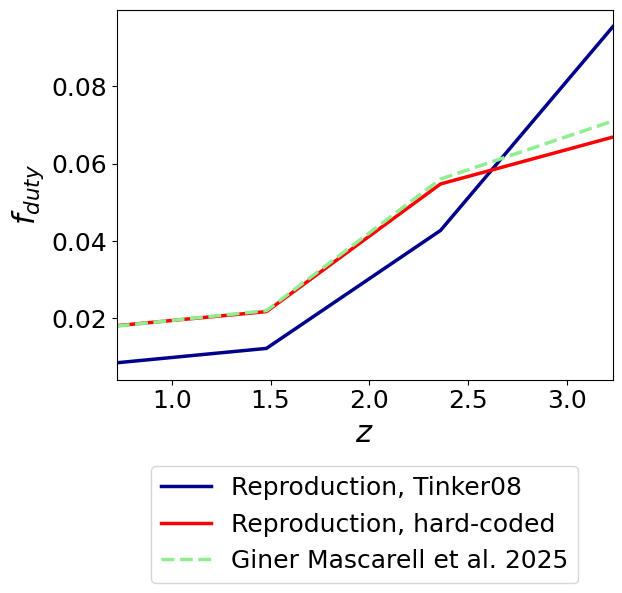

In [68]:
plt.plot(zbin, fduty_check, color = 'darkblue', linewidth = 2.5, label = 'Reproduction, Tinker08')
plt.plot(zbin, fduty_check2, color = 'red', linewidth = 2.5, label = 'Reproduction, hard-coded')
plt.plot(zbin, fduty, label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
plt.ylabel('$f_{duty}$')
plt.xlabel('$z$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(zbin[0], zbin[-1])
plt.show()

### Plot

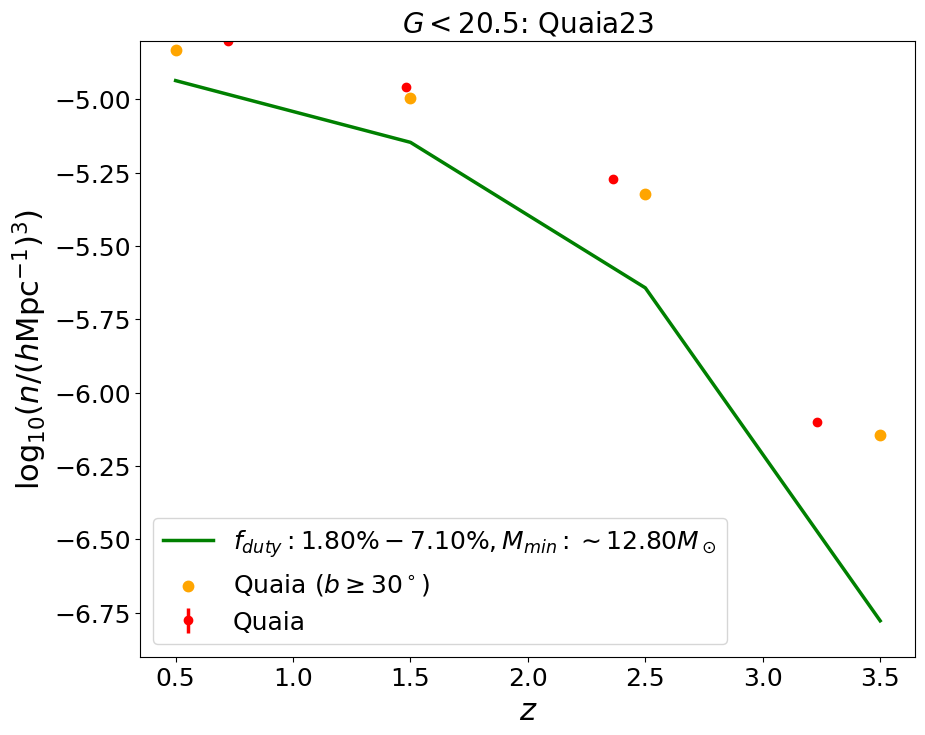

In [69]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
i = 1

n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1] for j in z_array]
plt.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_eff[j], cosmo = cosmos[i], recenter = False)[1] for j in z_array]
plt.plot(zbin_eff, np.log10(n_q_theory), linewidth = 2.5, 
         label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:\sim{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, M_min), color = 'green')
plt.scatter(zbin_eff, np.log10(n_q_b.value), linewidth = 2.5, marker = 'o', label = r'Quaia $(b\geq 30^\circ)$', color = 'orange', linestyle = 'None')
plt.title('$G<{}$: {}'.format(G_hi, labels[i]))

plt.xlabel('$z$')
plt.legend()
plt.ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
plt.ylim(-6.9, -4.8)

plt.show()

### Vary $M_{min}$

<>:30: SyntaxWarning: invalid escape sequence '\o'
<>:30: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_152916/1217432317.py:30: SyntaxWarning: invalid escape sequence '\o'
  cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/1217432317.py:9: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),


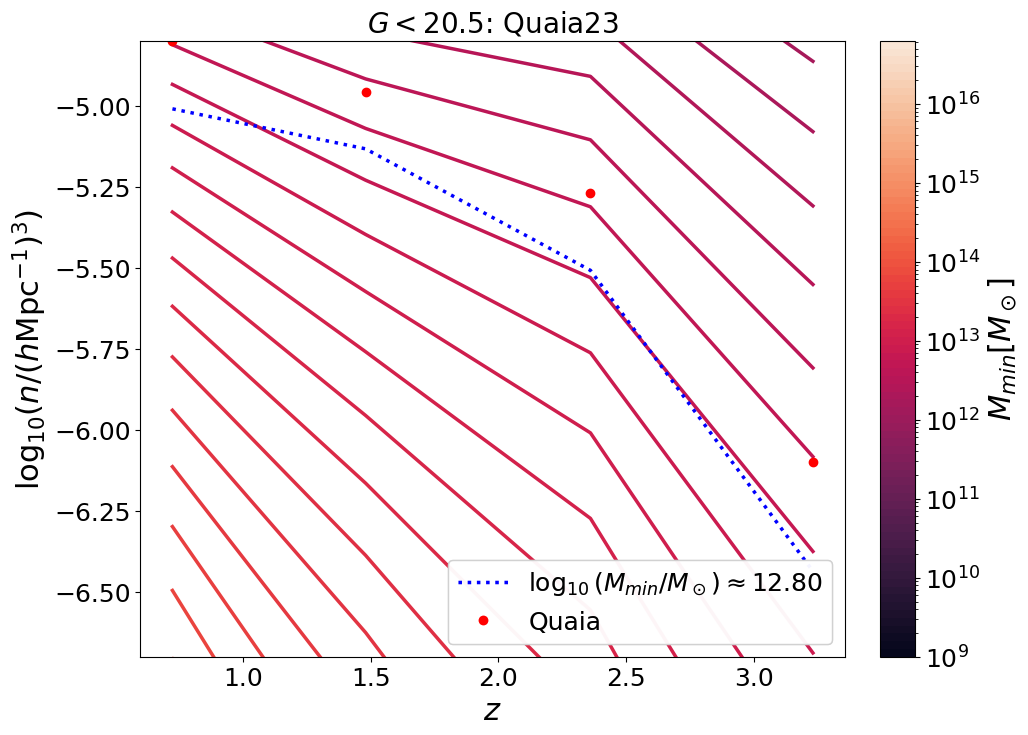

In [70]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])

for k in range(len(bins)):
    
    n_q_theory = [M(bins_M_min_array[k], n_m_array_2D[j][k], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1] for j in z_array]
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:[{:.2f}-{:.2f}] M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[0]), 
                                                                                                  np.log10(bins[-1])), color = cmap[k])
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1] for j in z_array]
ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'blue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

custom_lines = [Line2D([0], [0], color = 'blue', linestyle = ':', linewidth = 2.5, 
                       label = r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min)), 
                Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia')]
second_legend = ax1.legend(handles = custom_lines)
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(-6.7, -4.8)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

### Vary $f_{duty}$

In [71]:
fduty_array = np.logspace(-5,0, 51) #-4
n_m_array_3D = []
for i in z_array:

    n_m_array_3D.append([])
        
    for k in range(len(fduty_array)):

        n_m=np.ones(np.shape(bins))*fduty_array[k]
        n_m_array_3D[i].append(n_m)

<>:36: SyntaxWarning: invalid escape sequence '\o'
<>:36: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_152916/3582948278.py:36: SyntaxWarning: invalid escape sequence '\o'
  cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/3582948278.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),


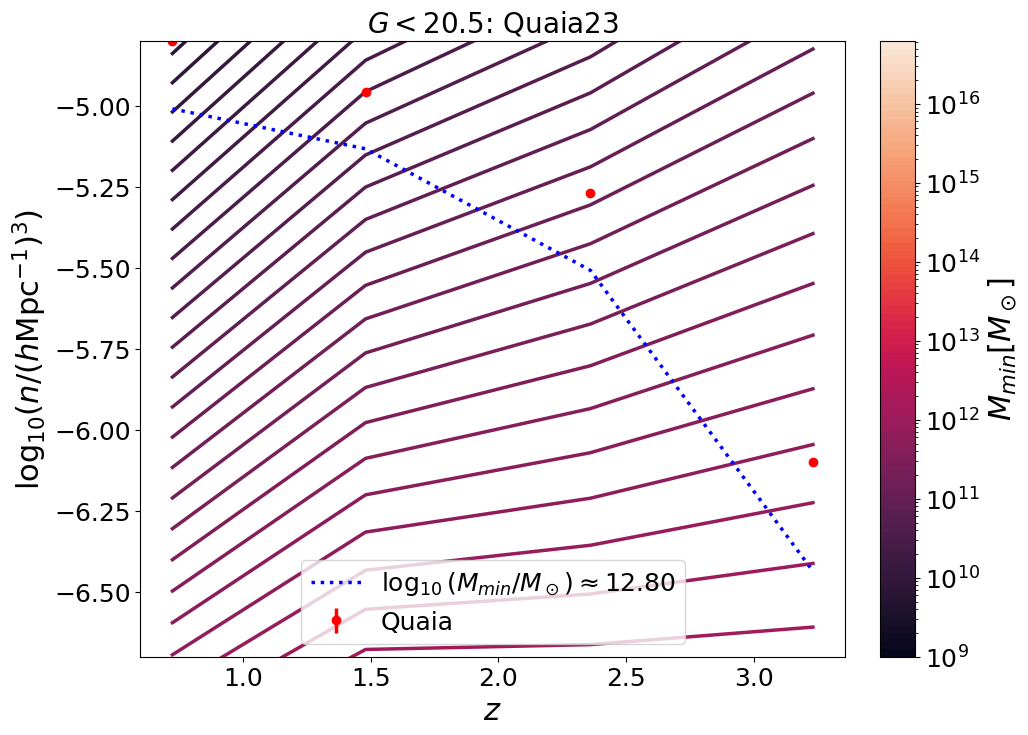

In [72]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
i = 1
# l = np.random.randint(0, len(fduty_array), size = len(z_array))
for k in range(len(bins)):
    
    n_q_theory = [M(bins_M_min_array[k], n_m_array_3D[j][f[j]], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1] for j in z_array]
    plt.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             # label = r'$f_{{duty}}: {:.2f}\%, M_{{min}}:[{:.2f}-{:.2f}] M_\odot$'.format(fduty_array[l]*100, np.log10(bins[0]), 
             #                                                                                      np.log10(bins[-1])), 
             color = cmap[k])
    
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1] for j in z_array]
ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'blue', linestyle = ':', 
         label = r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min)) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

# custom_lines = [Line2D([0], [0], color = grey, linestyle = '-', linewidth = 2.5, 
#                        label = r'$f_{{duty}}: [{:.2f}, {:.2f}, {:.2f}, {:.2f}]\%, M_{{min}}:[{:.2f}-{:.2f}] M_\odot$'.format(*fduty_array[f]*100, 
#                                                                                                             np.log10(bins[0]), np.log10(bins[-1]))), 
#                 Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia')]
# second_legend = ax1.legend(handles = custom_lines, bbox_to_anchor = (0.5, -0.1), loc='upper center')
# fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(-6.7, -4.8)
ax1.legend()

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

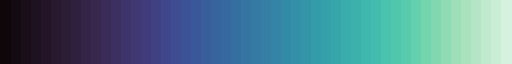

In [73]:
cmap_fduty = sns.color_palette("mako", n_colors = len(fduty_array))
palette_fduty = matplotlib.colors.ListedColormap(cmap_fduty)
palette_fduty

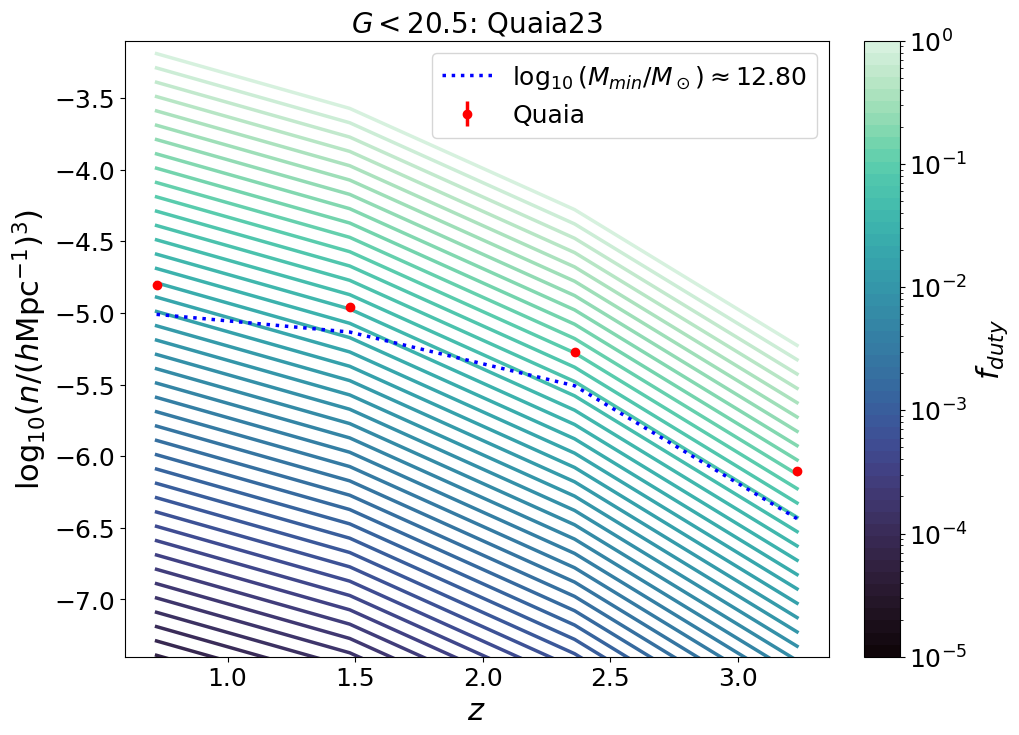

In [74]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
i = 1
l = 38

for k in range(len(fduty_array)):
    
    n_q_theory = [M(bins_M_min_array[l], n_m_array_3D[j][k], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1] for j in z_array]
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             color = cmap_fduty[k])
    
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1] for j in z_array]
ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'blue', linestyle = ':', 
         label = r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(np.log10(bins[l]))) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(-7.4, -3.1)
ax1.legend()

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_fduty, norm = matplotlib.colors.LogNorm(vmin=fduty_array[0], vmax = fduty_array[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$f_{duty}$')
plt.show()

# Perform $\chi^2$ fit
## $\chi_c^2=\sum \frac{\left(O_i-E_i\right)^2}{E_i}$

In [75]:
M_min_fit = []
for j in z_array:

    chi2 = []
    for m in bins:
        
        n_m=np.ones(np.shape(bins))*fduty[j]
        bins_m = np.logspace(np.log10(m), 16.8, 79)
        
        cf_2h_zbin, b_q = cf_2h(bins_m, n_m, a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j], recenter = False)
        chi2_m = (cf_zbin_percentile[labels[i]][j]-cf_2h_zbin)**2/cf_2h_zbin
        chi2_m[np.isnan(cf_2h_zbin)]=np.inf
        
        chi2.append(np.nansum(chi2_m))

    k = np.argmin(chi2)
    print(chi2[k])
    M_min_fit.append(bins[k])

np.log10(M_min_fit)

166.5150368694704
86.08104822027445
85.99772140240816
138.6861025900827


/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


array([ 9. ,  9. , 10.3, 11. ])

## Limit scales to $10\geq s \geq 85h^{-1}$ Mpc

In [76]:
# Create the bins array
rmin = 10 # 0.1 # start higher # 1.4 # 30
rmax = 85 # 200
nbins = 20 #90 #20
rbins_chi2 = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
quaia.recenter(rbins_chi2)

array([10.56468968, 11.75784393, 13.08575056, 14.56362822, 16.20841434,
       18.0389592 , 20.07624203, 22.34361137, 24.86705273, 27.67548634,
       30.80109866, 34.27971118, 38.15119101, 42.45990779, 47.25524215,
       52.59215168, 58.53180075, 65.14226153, 72.49929411, 80.68721477])

In [77]:
cf_chi2, cf_matter_chi2 = {label: [] for label in labels}, {label: [] for label in labels}
yerr_cf_chi2, b_cf_chi2 = {label: [] for label in labels}, {label: [] for label in labels}
b_cf_q_chi2 = {label: [] for label in labels}
i = 1
    
for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _ = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)

    # quasar correlation function
    cf, qq, qr = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
               rbins = rbins_chi2, Om0 = Omega_m_array[i], h = h_array[i], error = True)
    cf_chi2[labels[i]].append(cf)

    # scale factor
    a = a_median(tab_datahi_mask_zbin0)

    # matter correlation function
    H0 = h_array[i]*100 * u.km/u.s/u.Mpc
    rbins_Mpc = (quaia.recenter(rbins_chi2)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
    cf_matter = ccl.correlations.correlation_3d(cosmos[i], r=rbins_Mpc, a=a)
    cf_matter_chi2[labels[i]].append(cf_matter)

    # effective bias 
    b = np.sqrt(cf/cf_matter)
    b_cf_chi2[labels[i]].append(b)

    # yerr
    yerr=(1+cf)/np.sqrt(qq)
    yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
    yerr_cf_chi2[labels[i]].append(yerr)

    # qso bias
    b_cf_q_chi2[labels[i]].append(b_qso(cf, cf_matter, ccl.growth_rate(cosmos[i], a)))

G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin1.0zmax2.0: 0.28              467913 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin3.0zmax4.0: 0.21              28061 vs 35630


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_152916/3288299834.py:28: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_152916/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


In [78]:
M_min_fit = []
for j in z_array:

    chi2 = []
    for m in bins:
        
        n_m=np.ones(np.shape(bins))*fduty[j]
        bins_m = np.logspace(np.log10(m), 16.8, 79)
        
        cf_2h_zbin, b_q = cf_2h(bins_m, n_m, a_zbin[labels[i]][j], cosmos[i], cf_matter_chi2[labels[i]][j], recenter = False)
        chi2_m = (cf_chi2[labels[i]][j]-cf_2h_zbin)**2/cf_2h_zbin
        chi2_m[np.isnan(cf_2h_zbin)]=np.inf
        
        chi2.append(np.sum(chi2_m))

    k = np.argmin(chi2)
    print(chi2[k])
    M_min_fit.append(bins[k])

np.log10(M_min_fit)

0.22055390738289693
0.10592235450599222
0.13647778294677193
2.7375960243494726


/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


array([11.5, 11.5, 11.7, 12.2])

## Enforce the number density constraint
### Vary $f_{duty}$

In [79]:
M_min_fit, fduty_fit = [], []
for j in z_array:

    chi2 = np.zeros((len(bins), len(fduty_array)))

    for k in range(len(fduty_array)):
        
        for l in range(len(bins)):
        
            n_m=np.ones(np.shape(bins))*fduty_array[k]
            bins_m = np.logspace(np.log10(bins[l]), 16.8, 79)
        
            cf_2h_zbin, b_q = cf_2h(bins_m, n_m, a_zbin[labels[i]][j], cosmos[i], cf_matter_chi2[labels[i]][j], recenter = False)
            chi2_m = (cf_chi2[labels[i]][j]-cf_2h_zbin)**2/cf_2h_zbin
            chi2_m[np.isnan(chi2_m)]=np.inf
            chi2[l,k]=np.sum(chi2_m)

    ind = np.unravel_index(np.argmin(chi2), chi2.shape)
    print(chi2[ind])
    M_min_fit.append(bins[ind[0]])
    fduty_fit.append(fduty_array[ind[-1]])

np.log10(M_min_fit), np.log10(fduty_fit)

/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


0.22055390738289687
0.10592235450599218
0.1364777829467719
2.7375960243494726


/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: overflow encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/893485444.py:14: RuntimeWarning: invalid value encountered in divide
  chi2_m = (cf_chi2[labels[i]][j]-cf_2h_zbin)**2/cf_2h_zbin


(array([11.5, 11.5, 11.7, 12.2]), array([-4.3, -4.8, -5. , -4.9]))

### Enforce a hard limit on $n_q$

In [80]:
M_min_fit, fduty_fit = [], []
for j in z_array:

    chi2 = np.zeros((len(bins), len(fduty_array)))

    for k in range(len(fduty_array)):
        
        for l in range(len(bins)):
        
            n_m=np.ones(np.shape(bins))*fduty_array[k]
            bins_m = np.logspace(np.log10(bins[l]), 16.8, 79)
            
            cf_2h_zbin, b_q = cf_2h(bins_m, n_m, a_zbin[labels[i]][j], cosmos[i], cf_matter_chi2[labels[i]][j], recenter = False)
            chi2_m = (cf_chi2[labels[i]][j]-cf_2h_zbin)**2/cf_2h_zbin
            chi2_m[np.isnan(chi2_m)]=np.inf

            n_q_theory = M(bins_m, n_m, a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1]
            if np.abs(n_q_theory-n_q[j])/n_q[j]>=0.05:
                chi2_m = np.inf
            chi2[l,k]=np.sum(chi2_m)

    ind = np.unravel_index(np.argmin(chi2), chi2.shape)
    print(chi2[ind])
    M_min_fit.append(bins[ind[0]])
    fduty_fit.append(fduty_array[ind[-1]])

np.log10(M_min_fit), np.log10(fduty_fit)

/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


0.22055390738289693
0.10592235450599218
0.13647778294677193


/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: overflow encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/1067249660.py:14: RuntimeWarning: invalid value encountered in divide
  chi2_m = (cf_chi2[labels[i]][j]-cf_2h_zbin)**2/cf_2h_zbin


2.7375960243494726


(array([11.5, 11.5, 11.7, 12.2]), array([-3. , -3.1, -2.9, -2.4]))

## Try unweighted version: $\chi_c^2=\sum {\left(O_i-E_i\right)^2}$

In [81]:
M_min_fit, fduty_fit = [], []
for j in z_array:

    chi2 = np.zeros((len(bins), len(fduty_array)))

    for k in range(len(fduty_array)):
        
        for l in range(len(bins)):
        
            n_m=np.ones(np.shape(bins))*fduty_array[k]
            bins_m = np.logspace(np.log10(bins[l]), 16.8, 79)
            
            cf_2h_zbin, b_q = cf_2h(bins_m, n_m, a_zbin[labels[i]][j], cosmos[i], cf_matter_chi2[labels[i]][j], recenter = False)
            chi2_m = (cf_chi2[labels[i]][j]-cf_2h_zbin)**2
            chi2_m[np.isnan(chi2_m)]=np.inf

            n_q_theory = M(bins_m, n_m, a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1]
            if np.abs(n_q_theory-n_q[j])/n_q[j]>=0.05:
                chi2_m = np.inf
            chi2[l,k]=np.sum(chi2_m)

    ind = np.unravel_index(np.argmin(chi2), chi2.shape)
    print(chi2[ind])
    M_min_fit.append(bins[ind[0]])
    fduty_fit.append(fduty_array[ind[-1]])

np.log10(M_min_fit), np.log10(fduty_fit)

/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


0.005769151655897091
0.00360458781942536
0.012148948634732818
0.4253866676390185


/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: overflow encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)


(array([11.1, 11.3, 11.4, 12. ]), array([-3.4, -3.3, -3.3, -2.8]))

## Try weighted version: $\chi_c^2=\sum \frac{\left(O_i-E_i\right)^2}{\sigma_i^2}$
### Using Poisson variance

In [82]:
M_min_fit, fduty_fit = [], []
for j in z_array:

    chi2 = np.zeros((len(bins), len(fduty_array)))

    for k in range(len(fduty_array)):
        
        for l in range(len(bins)):
        
            n_m=np.ones(np.shape(bins))*fduty_array[k]
            bins_m = np.logspace(np.log10(bins[l]), 16.8, 79)
            
            cf_2h_zbin, b_q = cf_2h(bins_m, n_m, a_zbin[labels[i]][j], cosmos[i], cf_matter_chi2[labels[i]][j], recenter = False)
            chi2_m = (cf_chi2[labels[i]][j]-cf_2h_zbin)**2/yerr_cf_chi2[labels[i]][j]**2
            chi2_m[np.isnan(chi2_m)]=np.inf

            n_q_theory = M(bins_m, n_m, a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1]
            if np.abs(n_q_theory-n_q[j])/n_q[j]>=0.05:
                chi2_m = np.inf
            chi2[l,k]=np.sum(chi2_m)

    ind = np.unravel_index(np.argmin(chi2), chi2.shape)
    print(chi2[ind])
    M_min_fit.append(bins[ind[0]])
    fduty_fit.append(fduty_array[ind[-1]])

np.log10(M_min_fit), np.log10(fduty_fit)

/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


185.62852050711564
167.75114711602015
77.6593784910322


/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: overflow encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)


inf


(array([11.4, 11.5, 11.7,  9. ]), array([-3.1, -3.1, -2.9, -5. ]))

## Try scipy.minimize

In [83]:
def f0(x, a, cf_matter, yerr_cf, cf, cosmo = cosmo_quaia):
    
    fduty, M_min = x
    
    bins_m = np.logspace(M_min, 16.8, 79)
    n_m=np.ones(np.shape(bins_m))*fduty
        
    cf_2h_zbin, b_q = cf_2h(bins_m, n_m, a, cosmo, cf_matter, recenter = False)
    
    return np.sum((cf-cf_2h_zbin)**2/yerr_cf**2)

### Add a number density constraint

In [84]:
def constraint(x, a, n_q, cosmo = cosmo_quaia, error = 0.05):
    
    fduty, M_min = x
    
    bins_m = np.logspace(M_min, 16.8, 79)
    n_m=np.ones(np.shape(bins_m))*fduty
    
    n_q_theory = M(bins_m, n_m, a = a, cosmo = cosmo, recenter = False)[1]

    return error-np.abs(n_q_theory-n_q)/n_q

In [85]:
i = 1
errors = [0.01, 0.01, 0.01, 0.01]
res, M_min_fit, fduty_fit = [], [], []
for j in z_array:

    fun = lambda x: f0(x, a_zbin[labels[i]][j], cf_matter_chi2[labels[i]][j], yerr_cf_chi2[labels[i]][j], 
                                  cf_chi2[labels[i]][j])
    cons = ({'type': 'ineq', 'fun': lambda x: constraint(x, a_zbin[labels[i]][j], n_q[j], error = errors[j])})
    
    res.append(minimize(fun, [fduty[j], M_min_array[j]], bounds = ((0,1), (9, 15)), constraints = cons))
    M_min_fit.append(10**res[j].x[-1])
    fduty_fit.append(res[j].x[0])
    
np.log10(M_min_fit), np.log10(fduty_fit), res

/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


(array([11.43685735, 11.48754772, 11.69737864, 12.82      ]),
 array([-3.06623221, -3.09826959, -2.90821301, -1.14874165]),
 [ message: Optimization terminated successfully
   success: True
    status: 0
       fun: 185.239958643413
         x: [ 8.586e-04  1.144e+01]
       nit: 11
       jac: [ 0.000e+00 -1.277e-02]
      nfev: 39
      njev: 11,
   message: Optimization terminated successfully
   success: True
    status: 0
       fun: 167.5772062652276
         x: [ 7.975e-04  1.149e+01]
       nit: 11
       jac: [ 0.000e+00 -3.738e-04]
      nfev: 39
      njev: 11,
   message: Optimization terminated successfully
   success: True
    status: 0
       fun: 77.65316263901667
         x: [ 1.235e-03  1.170e+01]
       nit: 10
       jac: [ 0.000e+00  9.766e-04]
      nfev: 33
      njev: 10,
   message: Inequality constraints incompatible
   success: False
    status: 4
       fun: nan
         x: [ 7.100e-02  1.282e+01]
       nit: 1
       jac: [       nan        nan]
      nfev:

## Try with galactic magnitude mask

In [86]:
cf_chi2_b, cf_matter_chi2_b =  [], []
yerr_cf_chi2_b, a_zbin_b, b_cf_chi2_b = [], [], []
i = 1
b = [0,0,0,30]
# b = [30,30,30,30]
n_b, n_b_err = np.array([])/V.unit, np.array([])/V.unit

for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, selfunc_hi_bin0 = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask_type = 'b', b = b[j])

    # quasar correlation function
    cf, qq, qr = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
               rbins = rbins_chi2, Om0 = Omega_m_array[i], h = h_array[i], error = True)
    cf_chi2_b.append(cf)

    # scale factor
    a = a_median(tab_datahi_mask_zbin0)
    a_zbin_b.append(a)

    # matter correlation function
    H0 = h_array[i]*100 * u.km/u.s/u.Mpc
    rbins_Mpc = (quaia.recenter(rbins_chi2)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
    cf_matter = ccl.correlations.correlation_3d(cosmo_quaia, r=rbins_Mpc, a=a)
    cf_matter_chi2_b.append(cf_matter)
    
    # yerr
    yerr=(1+cf)/np.sqrt(qq)
    yerr[cf<0]=np.sqrt((1+np.sqrt(cf/cf_matter)**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
    yerr_cf_chi2_b.append(yerr)
    
    # effective bias 
    b_cf_chi2_b.append(np.sqrt(cf/cf_matter))
    
    # number density
    N = len(tab_datahi_mask_zbin0)
    ra, dec = hp.pix2ang(NSIDE, range(len(selfunc_hi_bin0)), lonlat = True)
    c = SkyCoord(ra=ra*u.degree, dec=dec*u.degree)
    mask_datahi_bin0 = np.abs(c.galactic.b.value)>=b[j]
    f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bin0[mask_datahi_bin0]*hp.nside2pixarea(NSIDE))
    print(f_sky)
    zmax = quaia.comoving_dist(j+1, h = cosmo_quaia['h'], Om0 = cosmo_quaia['Omega_b']+cosmo_quaia['Omega_c']) #Mpc/h
    zmin = quaia.comoving_dist(j, h = cosmo_quaia['h'], Om0 = cosmo_quaia['Omega_b']+cosmo_quaia['Omega_c']) #Mpc/h
    V = f_sky*(4/3*np.pi*(zmax**3-zmin**3)) 
    print(zmax, zmin)
    n_b = np.append(n_b,N/V)
    n_b_err = np.append(n_b_err,np.sqrt(N)/V) # Poisson error

G20.5_zmin0.0zmax1.0: 0.00              324336 vs 324336


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.43414768077284194
2256.4746623495225 Mpc / littleh 0.0 Mpc / littleh
G20.5_zmin1.0zmax2.0: 0.00              648196 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.4513665926411453
3500.7663810913928 Mpc / littleh 2256.4746623495225 Mpc / littleh
G20.5_zmin2.0zmax3.0: 0.00              286508 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.37243235700761895
4274.343647538735 Mpc / littleh 3500.7663810913928 Mpc / littleh
G20.5_zmin3.0zmax4.0: 0.23              27584 vs 35630


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.2514128901965475
4808.924175556744 Mpc / littleh 4274.343647538735 Mpc / littleh


/tmp/ipykernel_152916/3914038283.py:32: RuntimeWarning: invalid value encountered in sqrt
  yerr[cf<0]=np.sqrt((1+np.sqrt(cf/cf_matter)**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
/tmp/ipykernel_152916/3914038283.py:36: RuntimeWarning: invalid value encountered in sqrt
  b_cf_chi2_b.append(np.sqrt(cf/cf_matter))


In [87]:
i = 1
errors = [0.01, 0.01, 0.01, 0.01]
res, M_min_fit, fduty_fit = [], [], []
for j in z_array:

    fun = lambda x: f0(x, a_zbin_b[j], cf_matter_chi2_b[j], yerr_cf_chi2_b[j], 
                                  cf_chi2_b[j])
    cons = ({'type': 'ineq', 'fun': lambda x: constraint(x, a_zbin_b[j], n_b[j].value, error = errors[j])})
    
    res.append(minimize(fun, [fduty[j], M_min_array[j]], bounds = ((0,1), (9, 15)), constraints = cons))
    M_min_fit.append(10**res[j].x[-1])
    fduty_fit.append(res[j].x[0])
    
np.log10(M_min_fit), np.log10(fduty_fit), res

(array([11.62433679, 11.5471294 , 11.78700429, 12.82      ]),
 array([-2.8923143 , -3.03465881, -2.79484324, -1.14874165]),
 [ message: Optimization terminated successfully
   success: True
    status: 0
       fun: 391.21370946502935
         x: [ 1.281e-03  1.162e+01]
       nit: 8
       jac: [ 0.000e+00  1.175e-03]
      nfev: 27
      njev: 8,
   message: Optimization terminated successfully
   success: True
    status: 0
       fun: 307.37065285312264
         x: [ 9.233e-04  1.155e+01]
       nit: 7
       jac: [ 0.000e+00 -1.475e-02]
      nfev: 24
      njev: 7,
   message: Optimization terminated successfully
   success: True
    status: 0
       fun: 183.1409365419448
         x: [ 1.604e-03  1.179e+01]
       nit: 9
       jac: [ 1.907e-06 -3.681e-04]
      nfev: 29
      njev: 9,
   message: Inequality constraints incompatible
   success: False
    status: 4
       fun: nan
         x: [ 7.100e-02  1.282e+01]
       nit: 1
       jac: [       nan        nan]
      nfev: 3


## Limit scales to $30\geq s \geq 80h^{-1}$ Mpc

In [88]:
# Create the bins array
rmin = 30 # 0.1 # start higher # 1.4 # 30
rmax = 80 # 200
nbins = 20 #90 #20
rbins_desi = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'linear' 
quaia.recenter(rbins_desi)

array([31.25, 33.75, 36.25, 38.75, 41.25, 43.75, 46.25, 48.75, 51.25,
       53.75, 56.25, 58.75, 61.25, 63.75, 66.25, 68.75, 71.25, 73.75,
       76.25, 78.75])

In [89]:
cf_chi2_b, cf_matter_chi2_b =  [], []
yerr_cf_chi2_b, a_zbin_b, b_cf_chi2_b = [], [], []
i = 1
b = [0,0,0,30]
# b = [30,30,30,30]
n_b, n_b_err = np.array([])/V.unit, np.array([])/V.unit

for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, selfunc_hi_bin0 = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask_type = 'b', b = b[j])

    # quasar correlation function
    cf, qq, qr = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
               rbins = rbins_desi, Om0 = Omega_m_array[i], h = h_array[i], error = True)
    cf_chi2_b.append(cf)

    # scale factor
    a = a_median(tab_datahi_mask_zbin0)
    a_zbin_b.append(a)

    # matter correlation function
    H0 = h_array[i]*100 * u.km/u.s/u.Mpc
    rbins_Mpc = (quaia.recenter(rbins_desi)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
    cf_matter = ccl.correlations.correlation_3d(cosmo_quaia, r=rbins_Mpc, a=a)
    cf_matter_chi2_b.append(cf_matter)
    
    # yerr
    yerr=(1+cf)/np.sqrt(qq)
    yerr[cf<0]=np.sqrt((1+np.sqrt(cf/cf_matter)**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
    yerr_cf_chi2_b.append(yerr)
    
    # effective bias 
    b_cf_chi2_b.append(np.sqrt(cf/cf_matter))
    
    # number density
    N = len(tab_datahi_mask_zbin0)
    ra, dec = hp.pix2ang(NSIDE, range(len(selfunc_hi_bin0)), lonlat = True)
    c = SkyCoord(ra=ra*u.degree, dec=dec*u.degree)
    mask_datahi_bin0 = np.abs(c.galactic.b.value)>=b[j]
    f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bin0[mask_datahi_bin0]*hp.nside2pixarea(NSIDE))
    print(f_sky)
    zmax = quaia.comoving_dist(j+1, h = cosmo_quaia['h'], Om0 = cosmo_quaia['Omega_b']+cosmo_quaia['Omega_c']) #Mpc/h
    zmin = quaia.comoving_dist(j, h = cosmo_quaia['h'], Om0 = cosmo_quaia['Omega_b']+cosmo_quaia['Omega_c']) #Mpc/h
    V = f_sky*(4/3*np.pi*(zmax**3-zmin**3)) 
    print(zmax, zmin)
    n_b = np.append(n_b,N/V)
    n_b_err = np.append(n_b_err,np.sqrt(N)/V) # Poisson error

G20.5_zmin0.0zmax1.0: 0.00              324336 vs 324336


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.43414768077284194
2256.4746623495225 Mpc / littleh 0.0 Mpc / littleh
G20.5_zmin1.0zmax2.0: 0.00              648196 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.4513665926411453
3500.7663810913928 Mpc / littleh 2256.4746623495225 Mpc / littleh
G20.5_zmin2.0zmax3.0: 0.00              286508 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.37243235700761895
4274.343647538735 Mpc / littleh 3500.7663810913928 Mpc / littleh
G20.5_zmin3.0zmax4.0: 0.23              27584 vs 35630


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.2514128901965475
4808.924175556744 Mpc / littleh 4274.343647538735 Mpc / littleh


/tmp/ipykernel_152916/500659794.py:32: RuntimeWarning: invalid value encountered in sqrt
  yerr[cf<0]=np.sqrt((1+np.sqrt(cf/cf_matter)**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
/tmp/ipykernel_152916/500659794.py:36: RuntimeWarning: invalid value encountered in sqrt
  b_cf_chi2_b.append(np.sqrt(cf/cf_matter))


In [90]:
errors = [0.01, 0.01, 0.01, 0.01]
res, M_min_fit, fduty_fit = [], [], []
for j in z_array:

    fun = lambda x: f0(x, a_zbin_b[j], cf_matter_chi2_b[j], yerr_cf_chi2_b[j], 
                                  cf_chi2_b[j])
    cons = ({'type': 'ineq', 'fun': lambda x: constraint(x, a_zbin_b[j], n_b[j].value, error = errors[j])})
    
    res.append(minimize(fun, [fduty[j], M_min_array[j]], bounds = ((0,1), (9, 15)), constraints = cons))
    M_min_fit.append(10**res[j].x[-1])
    fduty_fit.append(res[j].x[0])
    
np.log10(M_min_fit), np.log10(fduty_fit), res

/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


(array([12.39314304, 12.14072527, 12.25229298, 12.82      ]),
 array([-2.09948738, -2.33884186, -2.07481484, -1.14874165]),
 [ message: Optimization terminated successfully
   success: True
    status: 0
       fun: 156.14798416311336
         x: [ 7.953e-03  1.239e+01]
       nit: 9
       jac: [ 1.907e-06 -3.297e-02]
      nfev: 33
      njev: 9,
   message: Optimization terminated successfully
   success: True
    status: 0
       fun: 143.19405400066134
         x: [ 4.583e-03  1.214e+01]
       nit: 6
       jac: [ 0.000e+00  1.522e-03]
      nfev: 22
      njev: 6,
   message: Optimization terminated successfully
   success: True
    status: 0
       fun: 78.48280470425799
         x: [ 8.418e-03  1.225e+01]
       nit: 6
       jac: [-2.861e-06  1.749e-02]
      nfev: 22
      njev: 6,
   message: Inequality constraints incompatible
   success: False
    status: 4
       fun: nan
         x: [ 7.100e-02  1.282e+01]
       nit: 1
       jac: [       nan        nan]
      nfev: 3


## Try a more aggressive galactic latitude mask

In [91]:
cf_chi2_b, cf_matter_chi2_b =  [], []
yerr_cf_chi2_b, a_zbin_b, b_cf_chi2_b = [], [], []
i = 1
b = [40,40,40,40]
# b = [30,30,30,30]
n_b, n_b_err = np.array([])/V.unit, np.array([])/V.unit

for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, selfunc_hi_bin0 = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask_type = 'b', b = b[j])

    # quasar correlation function
    cf, qq, qr = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
               rbins = rbins_chi2, Om0 = Omega_m_array[i], h = h_array[i], error = True)
    cf_chi2_b.append(cf)

    # scale factor
    a = a_median(tab_datahi_mask_zbin0)
    a_zbin_b.append(a)

    # matter correlation function
    H0 = h_array[i]*100 * u.km/u.s/u.Mpc
    rbins_Mpc = (quaia.recenter(rbins_chi2)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
    cf_matter = ccl.correlations.correlation_3d(cosmo_quaia, r=rbins_Mpc, a=a)
    cf_matter_chi2_b.append(cf_matter)
    
    # yerr
    yerr=(1+cf)/np.sqrt(qq)
    yerr[cf<0]=np.sqrt((1+np.sqrt(cf/cf_matter)**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
    yerr_cf_chi2_b.append(yerr)
    
    # effective bias 
    b_cf_chi2_b.append(np.sqrt(cf/cf_matter))
    
    # number density
    N = len(tab_datahi_mask_zbin0)
    ra, dec = hp.pix2ang(NSIDE, range(len(selfunc_hi_bin0)), lonlat = True)
    c = SkyCoord(ra=ra*u.degree, dec=dec*u.degree)
    mask_datahi_bin0 = np.abs(c.galactic.b.value)>=b[j]
    f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bin0[mask_datahi_bin0]*hp.nside2pixarea(NSIDE))
    print(f_sky)
    zmax = quaia.comoving_dist(j+1, h = cosmo_quaia['h'], Om0 = cosmo_quaia['Omega_b']+cosmo_quaia['Omega_c']) #Mpc/h
    zmin = quaia.comoving_dist(j, h = cosmo_quaia['h'], Om0 = cosmo_quaia['Omega_b']+cosmo_quaia['Omega_c']) #Mpc/h
    V = f_sky*(4/3*np.pi*(zmax**3-zmin**3)) 
    print(zmax, zmin)
    n_b = np.append(n_b,N/V)
    n_b_err = np.append(n_b_err,np.sqrt(N)/V) # Poisson error

G20.5_zmin0.0zmax1.0: 0.50              162745 vs 324336


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.21332225538726726
2256.4746623495225 Mpc / littleh 0.0 Mpc / littleh
G20.5_zmin1.0zmax2.0: 0.48              338833 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.23312332275281844
3500.7663810913928 Mpc / littleh 2256.4746623495225 Mpc / littleh
G20.5_zmin2.0zmax3.0: 0.45              157854 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.19897219702094693
4274.343647538735 Mpc / littleh 3500.7663810913928 Mpc / littleh
G20.5_zmin3.0zmax4.0: 0.41              20875 vs 35630


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.18543561357824762
4808.924175556744 Mpc / littleh 4274.343647538735 Mpc / littleh


/tmp/ipykernel_152916/1566736842.py:32: RuntimeWarning: invalid value encountered in sqrt
  yerr[cf<0]=np.sqrt((1+np.sqrt(cf/cf_matter)**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
/tmp/ipykernel_152916/1566736842.py:36: RuntimeWarning: invalid value encountered in sqrt
  b_cf_chi2_b.append(np.sqrt(cf/cf_matter))


In [92]:
errors = [0.01, 0.01, 0.01, 0.01]
res, M_min_fit, fduty_fit = [], [], []
for j in z_array:

    fun = lambda x: f0(x, a_zbin_b[j], cf_matter_chi2_b[j], yerr_cf_chi2_b[j], 
                                  cf_chi2_b[j])
    cons = ({'type': 'ineq', 'fun': lambda x: constraint(x, a_zbin_b[j], n_b[j].value, error = errors[j])})
    
    res.append(minimize(fun, [fduty[j], M_min_array[j]], bounds = ((0,1), (9, 15)), constraints = cons))
    M_min_fit.append(10**res[j].x[-1])
    fduty_fit.append(res[j].x[0])
    
np.log10(M_min_fit), np.log10(fduty_fit), res

/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


(array([11.39091882, 11.43561149, 11.63365793, 12.82      ]),
 array([-3.10785421, -3.15309058, -2.99306021, -1.14874165]),
 [ message: Optimization terminated successfully
   success: True
    status: 0
       fun: 97.32543519907945
         x: [ 7.801e-04  1.139e+01]
       nit: 11
       jac: [ 9.537e-07 -1.044e-02]
      nfev: 40
      njev: 11,
   message: Optimization terminated successfully
   success: True
    status: 0
       fun: 122.74801884175666
         x: [ 7.029e-04  1.144e+01]
       nit: 9
       jac: [ 9.537e-07 -1.647e-03]
      nfev: 29
      njev: 9,
   message: Optimization terminated successfully
   success: True
    status: 0
       fun: 46.337469001607325
         x: [ 1.016e-03  1.163e+01]
       nit: 10
       jac: [ 0.000e+00  3.776e-03]
      nfev: 33
      njev: 10,
   message: Inequality constraints incompatible
   success: False
    status: 4
       fun: nan
         x: [ 7.100e-02  1.282e+01]
       nit: 1
       jac: [       nan        nan]
      nfev

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_152916/182752708.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')


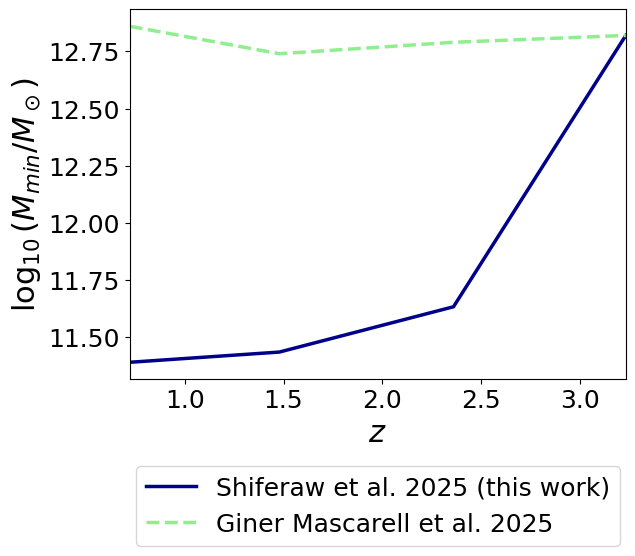

In [93]:
plt.plot(zbin, np.log10(M_min_fit), color = 'darkblue', linewidth = 2.5, label = 'Shiferaw et al. 2025 (this work)')
plt.plot(zbin, M_min_array, label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')
plt.xlabel('$z$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(zbin[0], zbin[-1])
plt.show()

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_152916/2872631476.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(f_{duty})$')


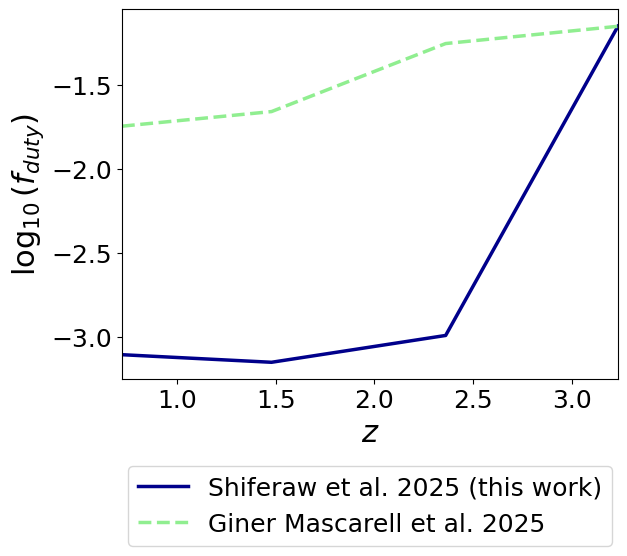

In [94]:
plt.plot(zbin, np.log10(fduty_fit), color = 'darkblue', linewidth = 2.5, label = 'Shiferaw et al. 2025 (this work)')
plt.plot(zbin, np.log10(fduty), label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
plt.ylabel('$\log_{10}(f_{duty})$')
plt.xlabel('$z$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(zbin[0], zbin[-1])
plt.show()

### Compare to no mask

In [95]:
cf_chi2_none, cf_matter_chi2_none =  [], []
yerr_cf_chi2_none, a_zbin_none, b_cf_chi2_none = [], [], []
i = 1
b_none = [0, 0, 0, 0]

for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, selfunc_hi_bin0 = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask_type = 'b', b = b[j])

    # quasar correlation function
    cf, qq, qr = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
               rbins = rbins_chi2, Om0 = Omega_m_array[i], h = h_array[i], error = True)
    cf_chi2_none.append(cf)

    # scale factor
    a = a_median(tab_datahi_mask_zbin0)
    a_zbin_none.append(a)

    # matter correlation function
    H0 = h_array[i]*100 * u.km/u.s/u.Mpc
    rbins_Mpc = (quaia.recenter(rbins_chi2)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
    cf_matter = ccl.correlations.correlation_3d(cosmo_quaia, r=rbins_Mpc, a=a)
    cf_matter_chi2_none.append(cf_matter)
    
    # yerr
    yerr=(1+cf)/np.sqrt(qq)
    yerr[cf<0]=np.sqrt((1+np.sqrt(cf/cf_matter)**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
    yerr_cf_chi2_none.append(yerr)
    
    # effective bias 
    b_cf_chi2_none.append(np.sqrt(cf/cf_matter))

G20.5_zmin0.0zmax1.0: 0.50              162745 vs 324336


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin1.0zmax2.0: 0.48              338833 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin2.0zmax3.0: 0.45              157854 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin3.0zmax4.0: 0.41              20875 vs 35630


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_152916/2526221218.py:30: RuntimeWarning: invalid value encountered in sqrt
  yerr[cf<0]=np.sqrt((1+np.sqrt(cf/cf_matter)**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
/tmp/ipykernel_152916/2526221218.py:34: RuntimeWarning: invalid value encountered in sqrt
  b_cf_chi2_none.append(np.sqrt(cf/cf_matter))


<>:37: SyntaxWarning: invalid escape sequence '\g'
<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\g'
<>:41: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_152916/2680366934.py:37: SyntaxWarning: invalid escape sequence '\g'
  color = 'brown', yerr = yerr_cf_chi2_b[j], label = '$b_{{eff}}(s), |b|\geq {}^\circ$'.format(b[j]))
/tmp/ipykernel_152916/2680366934.py:41: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))


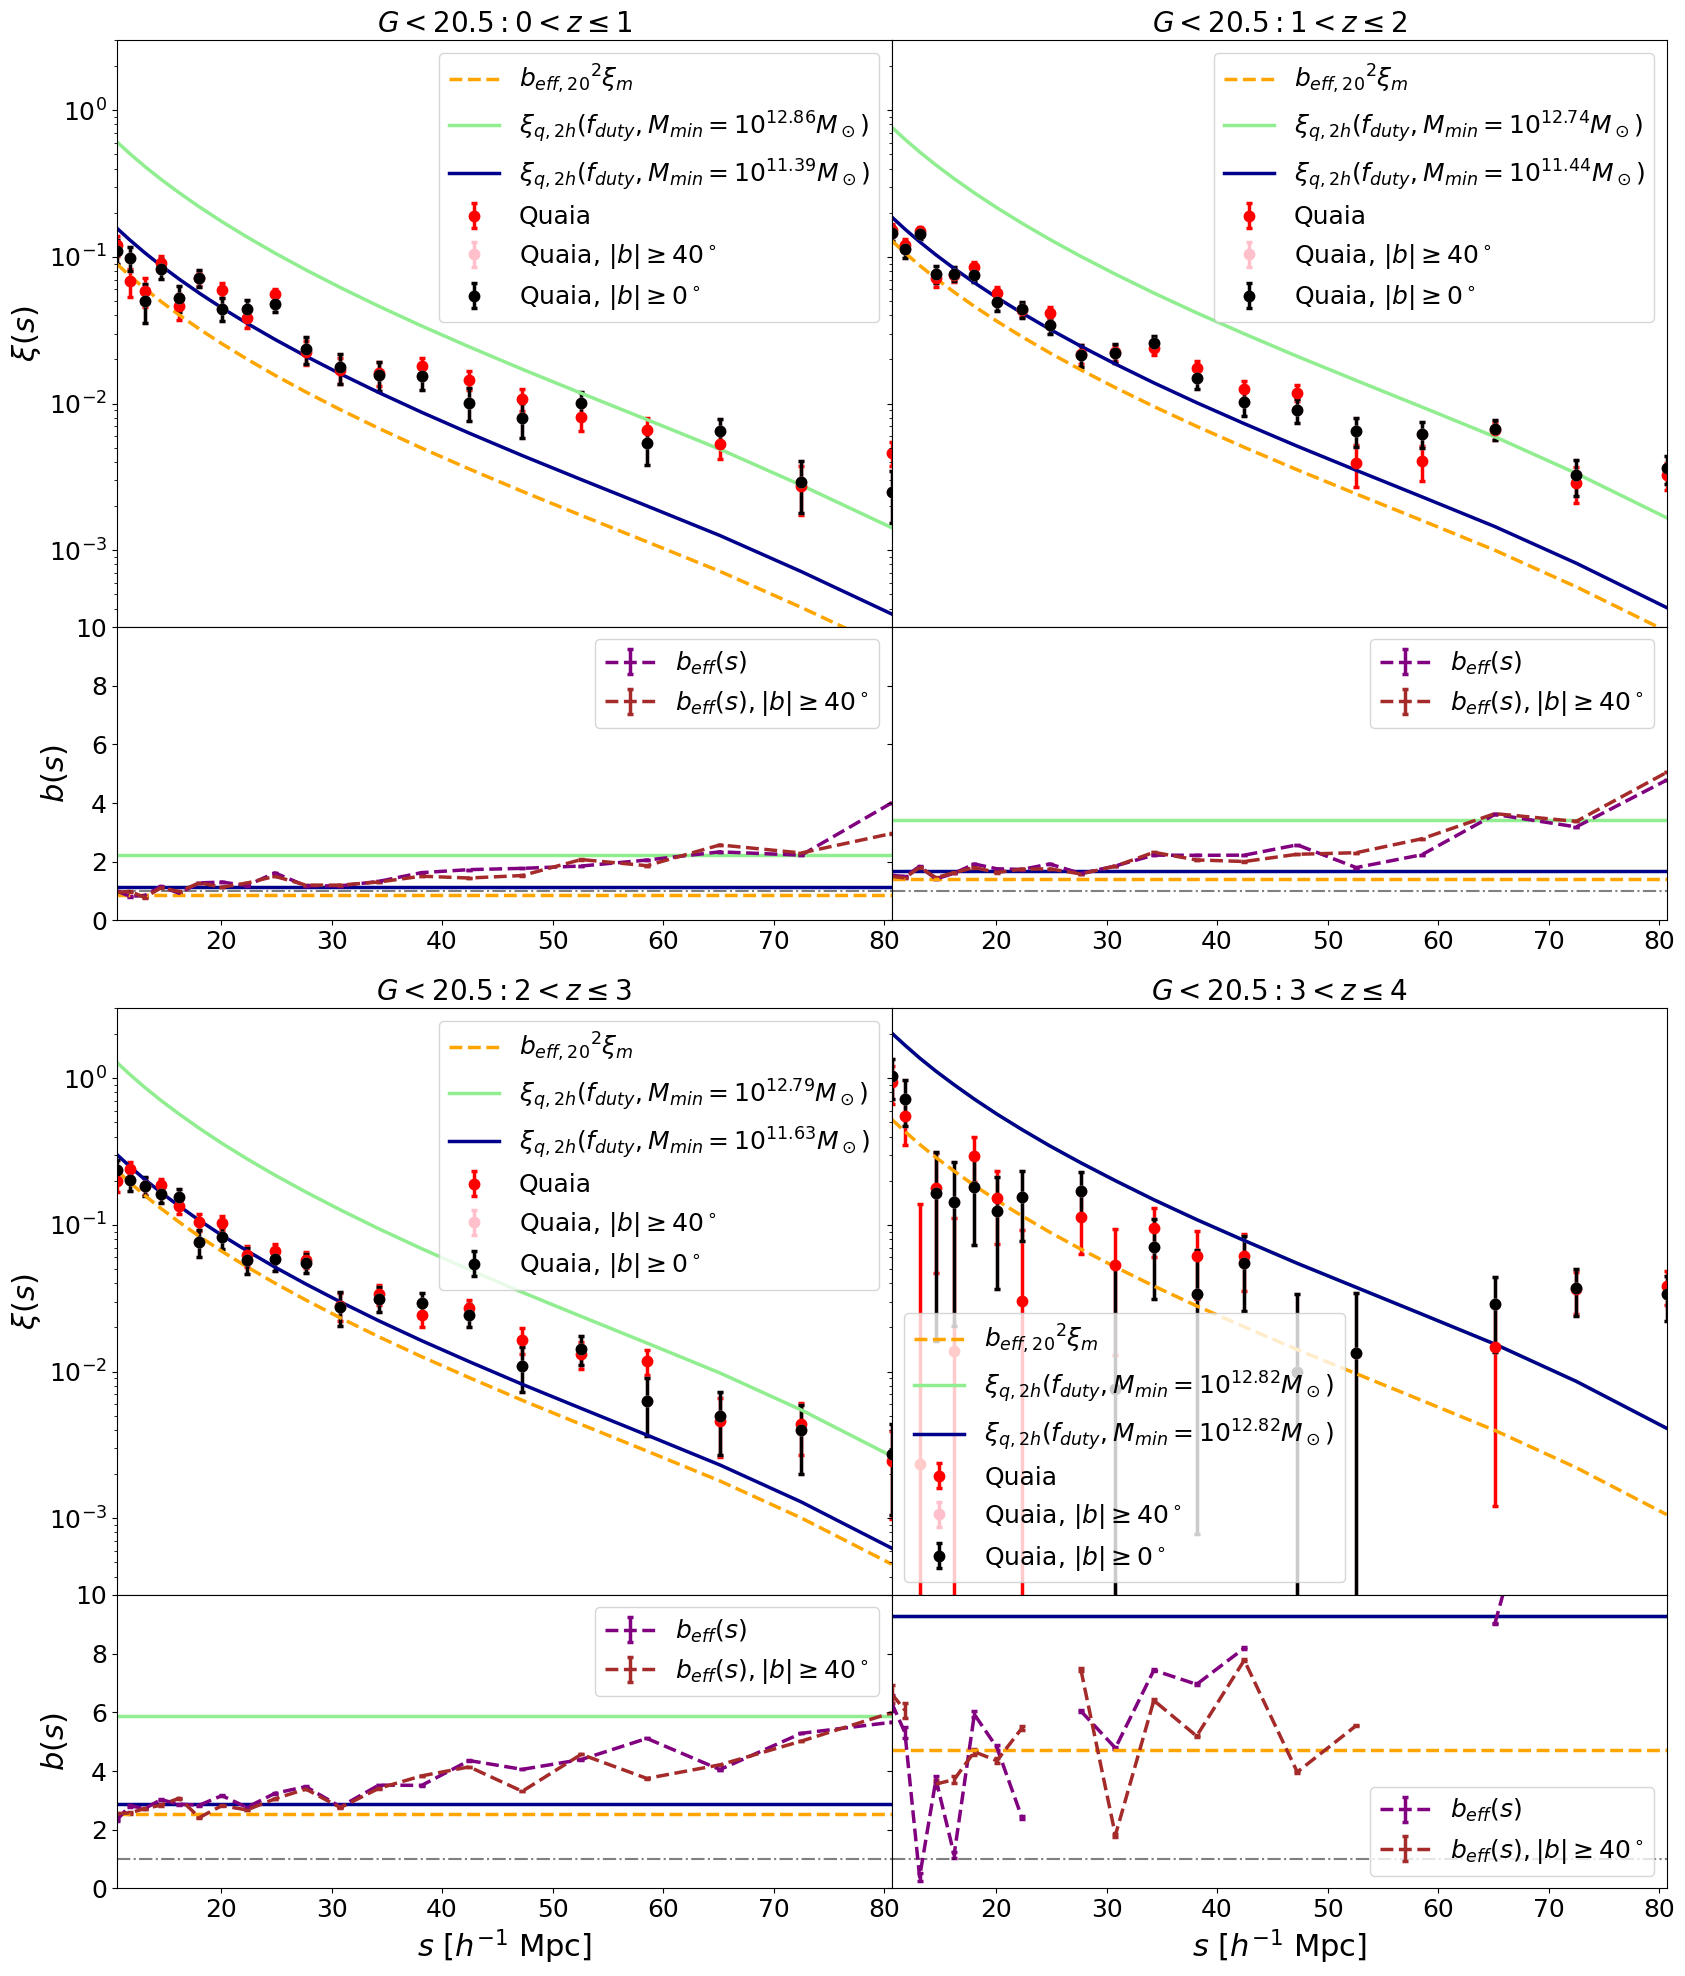

In [96]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.15, 1, 0.5], hspace = 0, wspace = 0)
rbins_plot = rbins_chi2

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
            
    ax1.errorbar(quaia.recenter(rbins_chi2), cf_chi2[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red',
                yerr = yerr_cf_chi2[labels[i]][j], markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.errorbar(quaia.recenter(rbins_plot), cf_chi2_b[j], linewidth = 2.5, marker = 'o', label = r'Quaia, $|b|\geq {}^\circ$'.format(40),
                 color = 'pink', yerr = yerr_cf_chi2_b[j], markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.errorbar(quaia.recenter(rbins_plot), cf_chi2_none[j], linewidth = 2.5, marker = 'o', label = r'Quaia, $|b|\geq {}^\circ$'.format(0),
                 color = 'black', yerr = yerr_cf_chi2_none[j], markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.plot(quaia.recenter(rbins_chi2), b_eff_cf20[j]**2*cf_matter_chi2[labels[i]][j], linewidth = 2.5,
             label = r'${b_{eff, 20}}^2\xi_m$', color = 'orange', linestyle = '--')

    # old fit
    cf_2h_zbin, b_q = cf_2h(bins_M_min[j], n_m_array[j], a_zbin[labels[i]][j], cosmos[i], cf_matter_chi2[labels[i]][j], recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5, 
             label = r'$\xi_{{q,2h}}(f_{{duty}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(M_min_array[j]), color = 'lightgreen')
    ax2.axhline(b_q, linewidth = 2.5, color = 'lightgreen')

    # plot new fit
    n_m=np.ones(np.shape(bins))*fduty[j]
    cf_2h_zbin, b_q = cf_2h(np.logspace(np.log10(M_min_fit[j]),16.8,79), n_m, a_zbin_b[j], cosmos[i], cf_matter_chi2_b[j], 
                            recenter = False)
    ax1.plot(quaia.recenter(rbins_plot), cf_2h_zbin, linewidth = 2.5,
             label = r'$\xi_{{q,2h}}(f_{{duty}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(M_min_fit[j])), color = 'darkblue')
    ax2.axhline(b_q, linewidth = 2.5, color = 'darkblue')

    ax2.errorbar(quaia.recenter(rbins_chi2), b_cf_chi2[labels[i]][j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5,
                 color = 'purple', yerr = yerr_cf_chi2[labels[i]][j], label = '$b_{eff}(s)$')
    ax2.errorbar(quaia.recenter(rbins_plot), b_cf_chi2_b[j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5,
                 color = 'brown', yerr = yerr_cf_chi2_b[j], label = '$b_{{eff}}(s), |b|\geq {}^\circ$'.format(b[j]))
    ax2.axhline(b_eff_cf20[j], linewidth = 2.5, color = 'orange', linestyle = '--')

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_plot)[0], quaia.recenter(rbins_plot)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 3)
    ax1.legend()

    ax2.axhline(1, linestyle = '-.', color = 'black', alpha = 0.5)
    ax2.set_xlim(quaia.recenter(rbins_plot)[0], quaia.recenter(rbins_plot)[-1])
    ax2.set_ylim(0, 10)
    ax2.legend()
    
    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    # else:
    #     ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

<>:40: SyntaxWarning: invalid escape sequence '\g'
<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:40: SyntaxWarning: invalid escape sequence '\g'
<>:46: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_152916/1686511724.py:40: SyntaxWarning: invalid escape sequence '\g'
  color = 'brown', yerr = yerr_cf_chi2_b[j], label = '$b_{eff}(s), |b|\geq 30^\circ$')
/tmp/ipykernel_152916/1686511724.py:46: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))


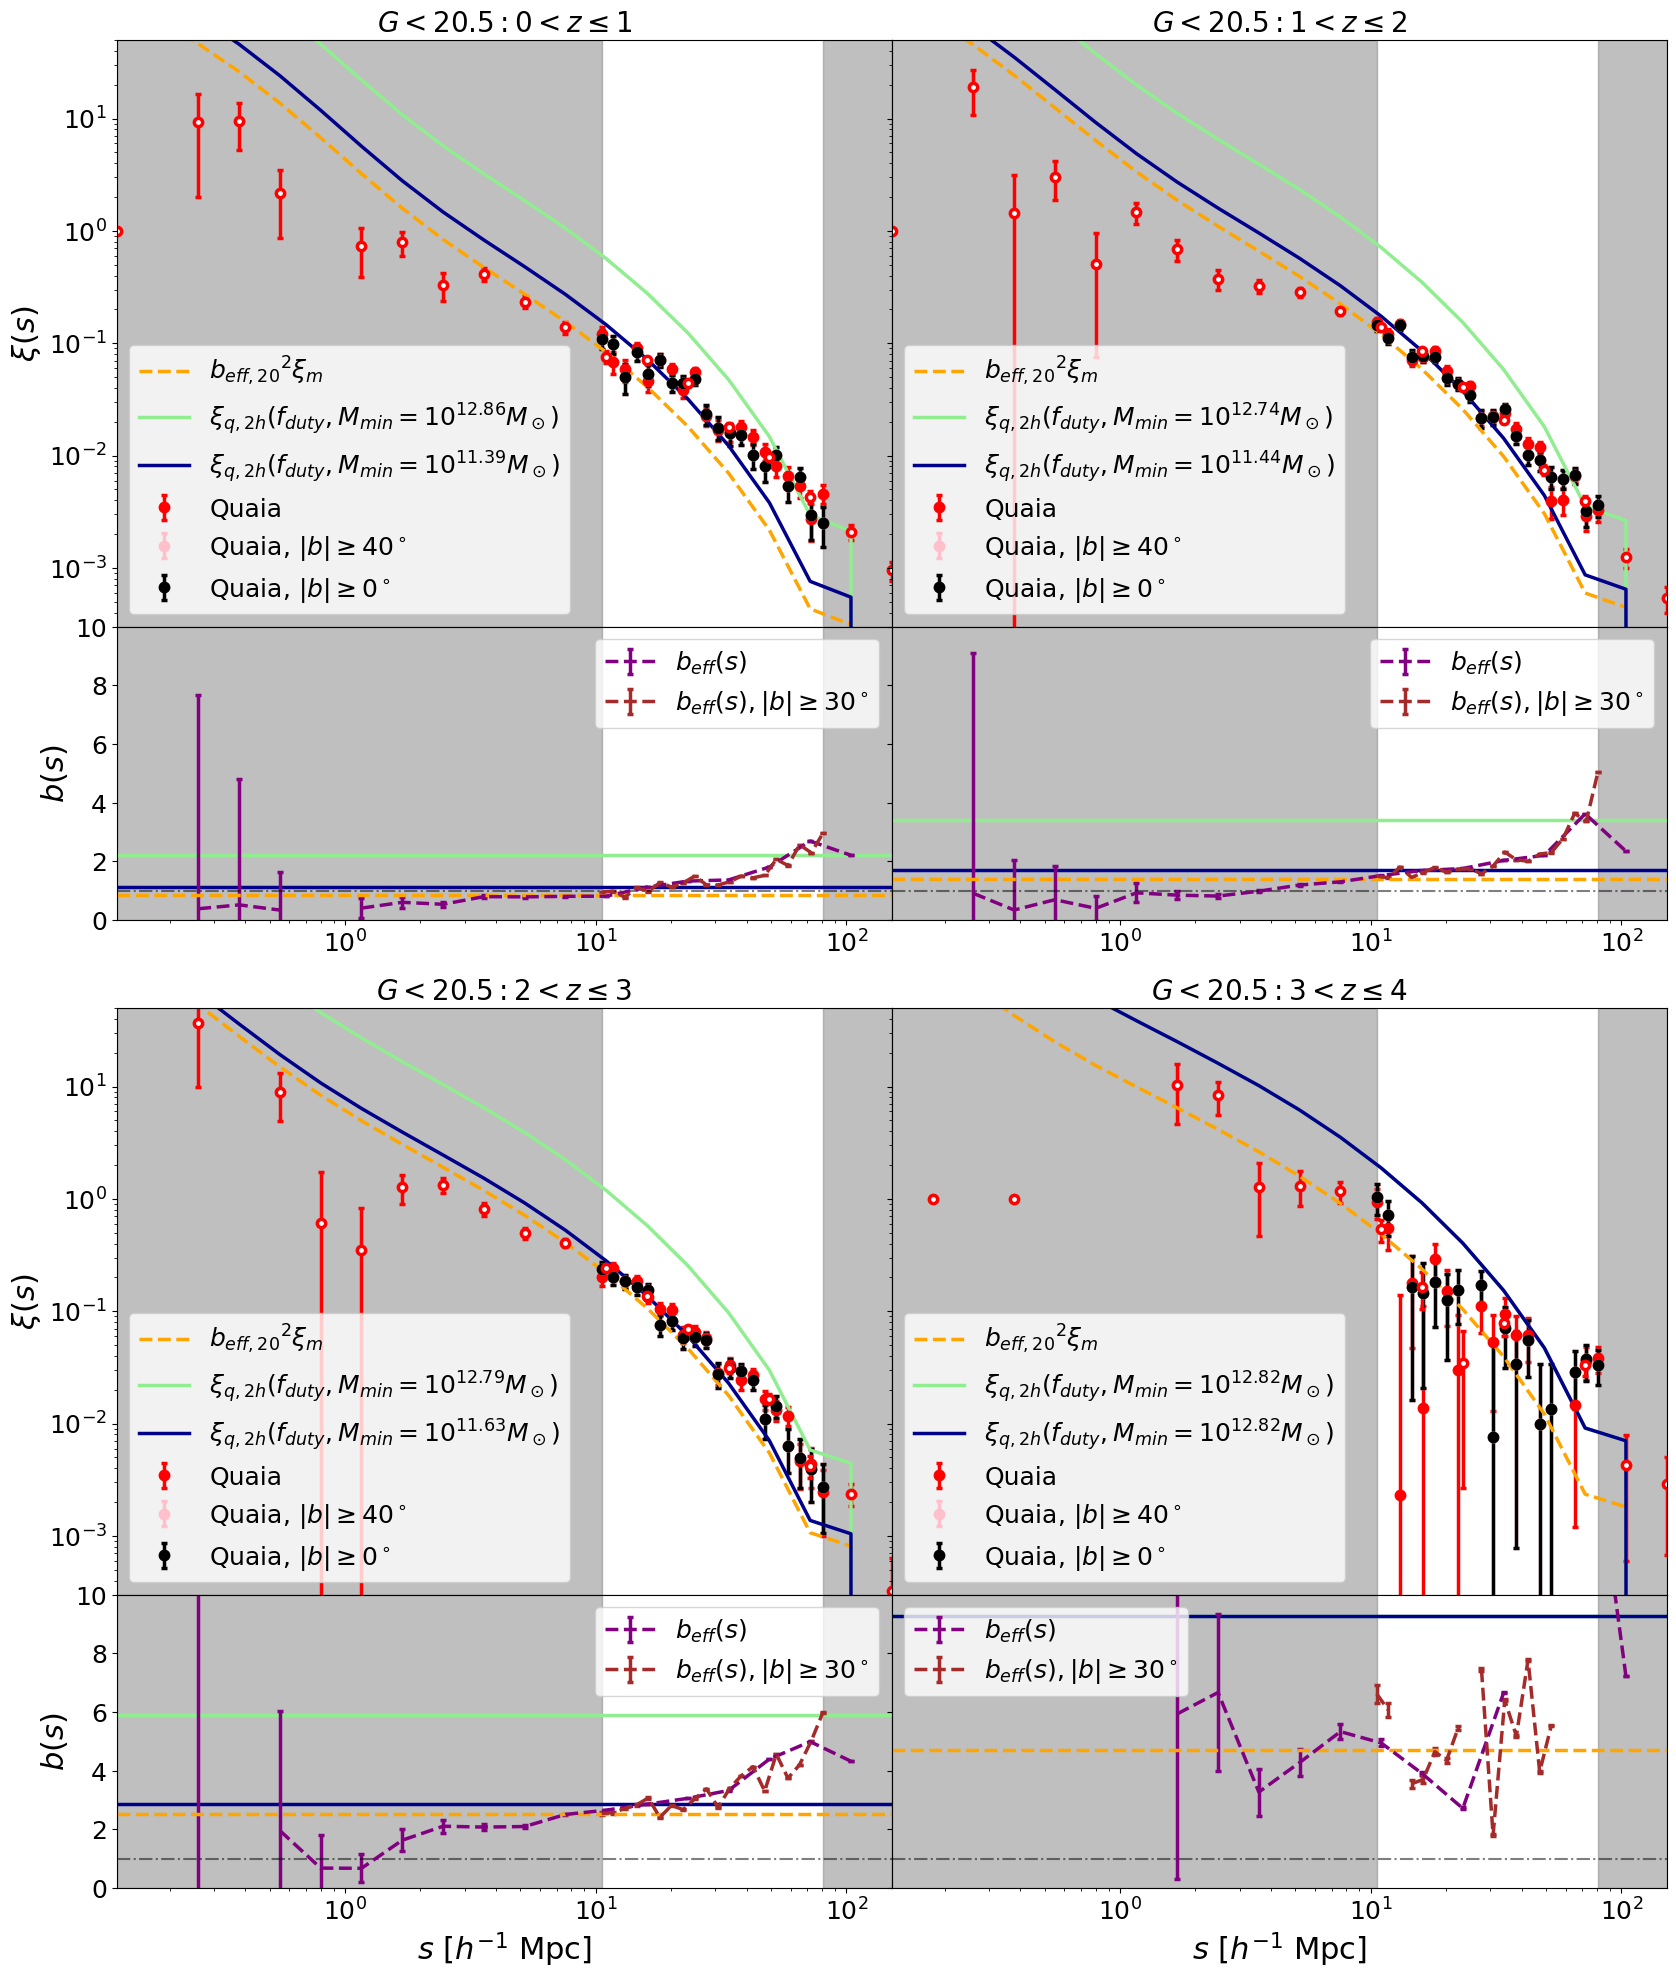

In [97]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.15, 1, 0.5], hspace = 0, wspace = 0)

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
            
    ax1.errorbar(quaia.recenter(rbins_chi2), cf_chi2[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red',
                yerr = yerr_cf_chi2[labels[i]][j], markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.errorbar(quaia.recenter(rbins_plot), cf_chi2_b[j], linewidth = 2.5, marker = 'o', label = r'Quaia, $|b|\geq {}^\circ$'.format(40),
                 color = 'pink', yerr = yerr_cf_chi2_b[j], markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.errorbar(quaia.recenter(rbins_plot), cf_chi2_none[j], linewidth = 2.5, marker = 'o', label = r'Quaia, $|b|\geq {}^\circ$'.format(0),
                 color = 'black', yerr = yerr_cf_chi2_none[j], markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', color = 'red', markerfacecolor = 'white',
                yerr = yerr_cf[labels[i]][j], markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.plot(quaia.recenter(rbins), b_eff_cf20[j]**2*cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5,
             label = r'${b_{eff, 20}}^2\xi_m$', color = 'orange', linestyle = '--')
    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins)[0], x2 = quaia.recenter(rbins_plot)[0], color = 'grey', alpha = 0.5)
    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_plot)[-1], x2 = quaia.recenter(rbins)[-1], color = 'grey', alpha = 0.5)

    # old fit, all scales
    cf_2h_zbin, b_q = cf_2h(bins_M_min[j], n_m_array[j], a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j], recenter = False)
    ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, color = 'lightgreen', 
             label = r'$\xi_{{q,2h}}(f_{{duty}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(M_min_array[j]))
    ax2.axhline(b_q, linewidth = 2.5, color = 'lightgreen')

    # plot new fit
    n_m=np.ones(np.shape(bins))*fduty[j]
    cf_2h_zbin, b_q = cf_2h(np.logspace(np.log10(M_min_fit[j]), 16.8, 79), n_m, a_zbin_b[j], cosmos[i], 
                            cf_matter_zbin_percentile[labels[i]][j], recenter = False)
    ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, label = r'$\xi_{{q,2h}}(f_{{duty}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(M_min_fit[j])),
             color = 'darkblue')
    ax2.axhline(b_q, linewidth = 2.5, color = 'darkblue')

    ax2.errorbar(quaia.recenter(rbins), b_cf[labels[i]][j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5,
                 color = 'purple', yerr = yerr_cf[labels[i]][j], label = '$b_{eff}(s)$')
    ax2.errorbar(quaia.recenter(rbins_plot), b_cf_chi2_b[j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5,
                 color = 'brown', yerr = yerr_cf_chi2_b[j], label = '$b_{eff}(s), |b|\geq 30^\circ$')
    ax2.axhline(b_eff_cf20[j], linewidth = 2.5, color = 'orange', linestyle = '--')
    ax2.fill_betweenx(np.linspace(0, 10), x1 = quaia.recenter(rbins)[0], x2 = quaia.recenter(rbins_plot)[0], color = 'grey', alpha = 0.5)
    ax2.fill_betweenx(np.linspace(0, 10), x1 = quaia.recenter(rbins_plot)[-1], x2 = quaia.recenter(rbins)[-1], color = 'grey', alpha = 0.5)

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)
    ax1.legend()

    ax2.axhline(1, linestyle = '-.', color = 'black', alpha = 0.5)
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 10)
    ax2.legend()
    
    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    # if scale == 'log':
    ax1.set_xscale('log')
    ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    # else:
    #     ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

### Check rough scale of small-scale suppression due to sparse number density: $V_{\text {per object }}=\frac{V}{N}=\frac{1}{\bar{n}}=r^3$

In [98]:
r = (1/np.array(n_q))**(1/3)
r

array([ 39.87511122,  44.94842854,  57.14411929, 108.04754734])

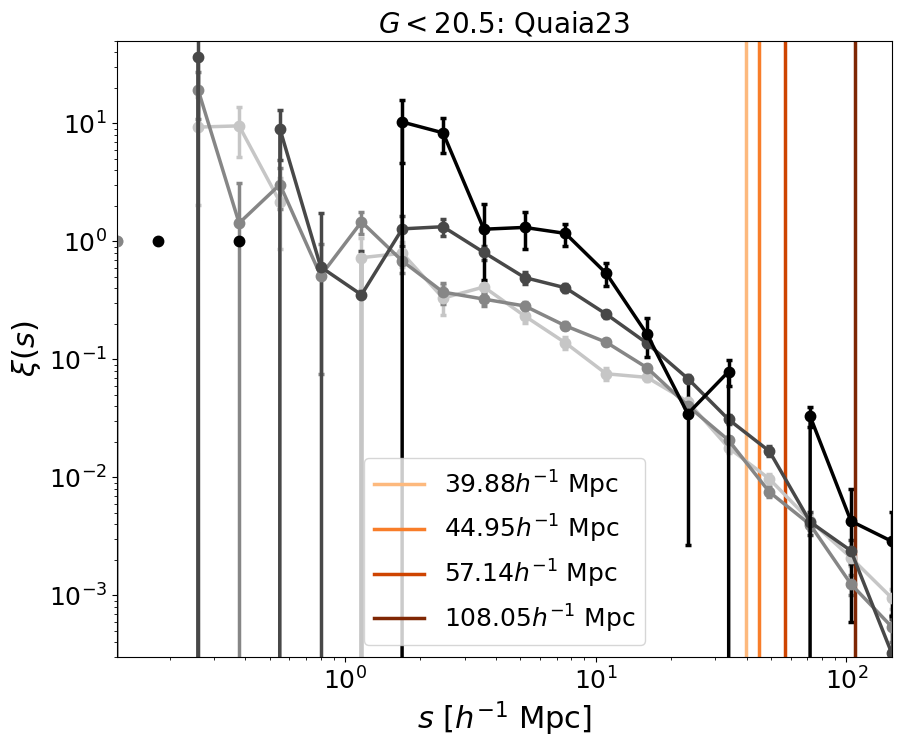

In [99]:
fig = plt.figure(figsize = (10, 8))
gs = gridspec.GridSpec(1, 1, hspace = 0, wspace = 0)

labels_cf = ['qq', r'$\xi_{2h}$']
    
ax1 = fig.add_subplot(gs[0])
# ax2 = fig.add_subplot(gs[1])

i = 1
for j in z_array:

    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', color = cmap_b[j], 
                 yerr = yerr_cf[labels[i]][j], markeredgewidth = 2.5, capsize = 2.5) #  markerfacecolor = 'white'
    ax1.axvline(r[j], linewidth = 2.5, label = r'${:.2f}h^{{-1}}$ Mpc'.format(r[j]), color = cmap_qq[j]) #  markerfacecolor = 'white'
#     cf_2h_zbin, b_q = cf_2h(bins_M_min[j], n_m_array[j], a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j], recenter = False)
#     ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, label = r'\xi_2h}',
#              color = cmap_mm[j], linestyle = '-')
#     ax1.plot(quaia.recenter(rbins), b_eff_cf20[j]**2*cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, linestyle = '--',
#              label = r'$b_{20}$ model', color = cmap_qq[j])

#     ax2.errorbar(quaia.recenter(rbins), b_cf[labels[i]][j], linewidth = 2.5, capsize = 2.5, markeredgewidth = 2.5, linestyle = '--',
#                  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[labels[i]][j])
#     ax2.axhline(b_q, linewidth = 2.5, color = cmaps[i][j])
    
ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
# ax1.set_xticklabels([])
ax1.set_ylim(3e-4, 5e1)

# custom_lines = [Line2D([0], [0], color = grey, marker = 'o', linestyle = 'none', linewidth = 2.5),
#                 Line2D([0], [0], color = green, marker = 'o', linestyle = '-', linewidth = 2.5), 
#                 Line2D([0], [0], color = orange, marker = 'o', linestyle = '--', linewidth = 2.5)]
# second_legend = ax1.legend(custom_lines, ['Quaia', r'$\xi_{q,2h}(f_{duty}, M_{min})$', r'${b_{eff, 20}}^2\xi_m$'], loc = 'upper right')
# ax1.add_artist(second_legend)

ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
# ax2.axhline(1, linestyle = '-.', color = 'black', zorder = 0, alpha = 0.5)
# ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
# ax2.set_ylim(0, 10)
ax1.legend()

ax1.set_ylabel(r'$\xi(s)$')
# ax2.set_ylabel(r'$b(s)$')

# if scale == 'log':
ax1.set_xscale('log')
# ax2.set_xscale('log')

plt.show()

<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:46: SyntaxWarning: invalid escape sequence '\o'
<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:46: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_152916/3564238767.py:36: SyntaxWarning: invalid escape sequence '\c'
  second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min), '$\chi^2$ minimization',
/tmp/ipykernel_152916/3564238767.py:46: SyntaxWarning: invalid escape sequence '\o'
  cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


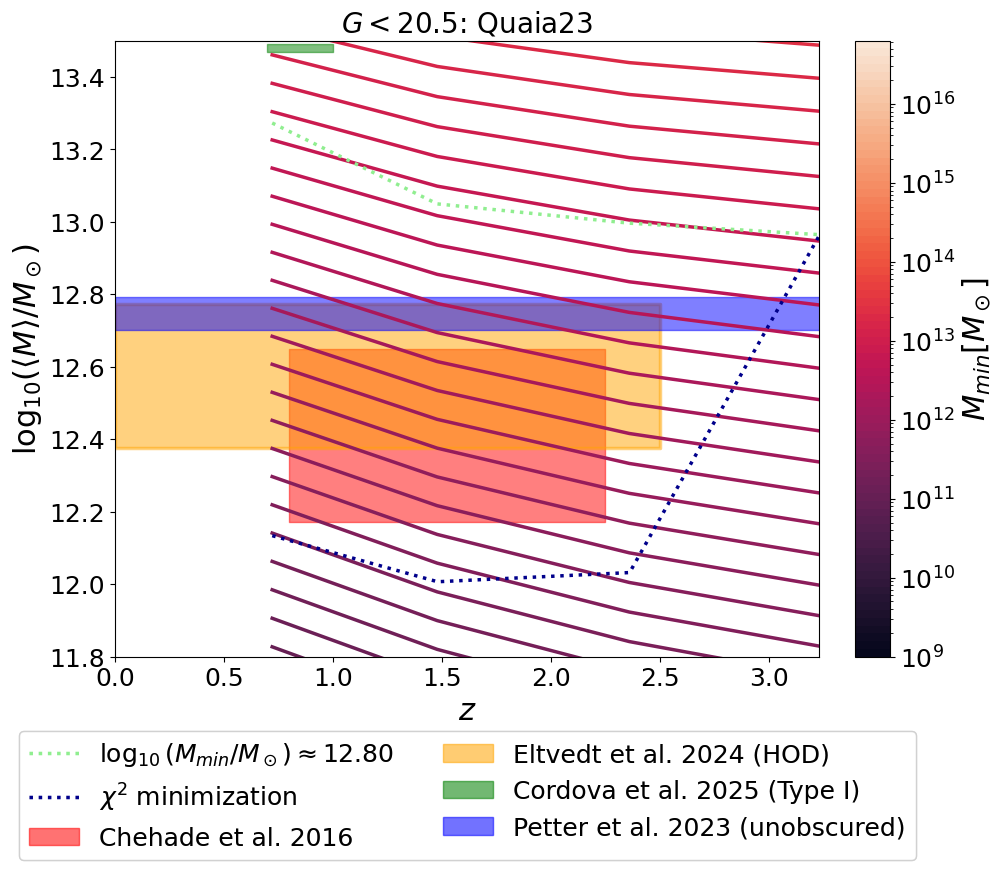

In [100]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
i = 1

for k in range(len(bins)):
    
    M_h = [M(bins_M_min_array[k], n_m_array_2D[j][k], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[0] for j in z_array]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, 
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
             color = cmap[k]) #, alpha = (1+k)/len(bins))
    
M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

# new fit
M_h = [M(np.logspace(np.log10(M_min_fit[j]), 16.8, 79), np.ones(np.shape(bins))*fduty[j], a = a_zbin_b[j], cosmo = cosmos[i], 
         recenter = False)[0] for j in z_array]
ax1.plot(1/np.array(a_zbin_b)-1, np.log10(M_h), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

z = np.linspace(0.8, 2.25)
ax1.fill_between(z, [np.log10(1e12/cosmo_quaia['h'])]*len(z), [np.log10(3e12/cosmo_quaia['h'])]*len(z), alpha = 0.5, label = 'Chehade et al. 2016', 
                 color = 'red')
ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/cosmo_quaia['h'])]*len(z), [np.log10(4e12/cosmo_quaia['h'])]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/cosmo_quaia['h'])]*len(z), [np.log10(10**12.62/cosmo_quaia['h'])]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min), '$\chi^2$ minimization',
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(0, zbin[-1])
ax1.set_ylim(11.8, 13.5)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

<>:32: SyntaxWarning: invalid escape sequence '\c'
<>:41: SyntaxWarning: invalid escape sequence '\o'
<>:32: SyntaxWarning: invalid escape sequence '\c'
<>:41: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_152916/3897801139.py:32: SyntaxWarning: invalid escape sequence '\c'
  label = '$\chi^2$ minimization'),
/tmp/ipykernel_152916/3897801139.py:41: SyntaxWarning: invalid escape sequence '\o'
  cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_152916/3897801139.py:10: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(zbin, np.log10(n_q_

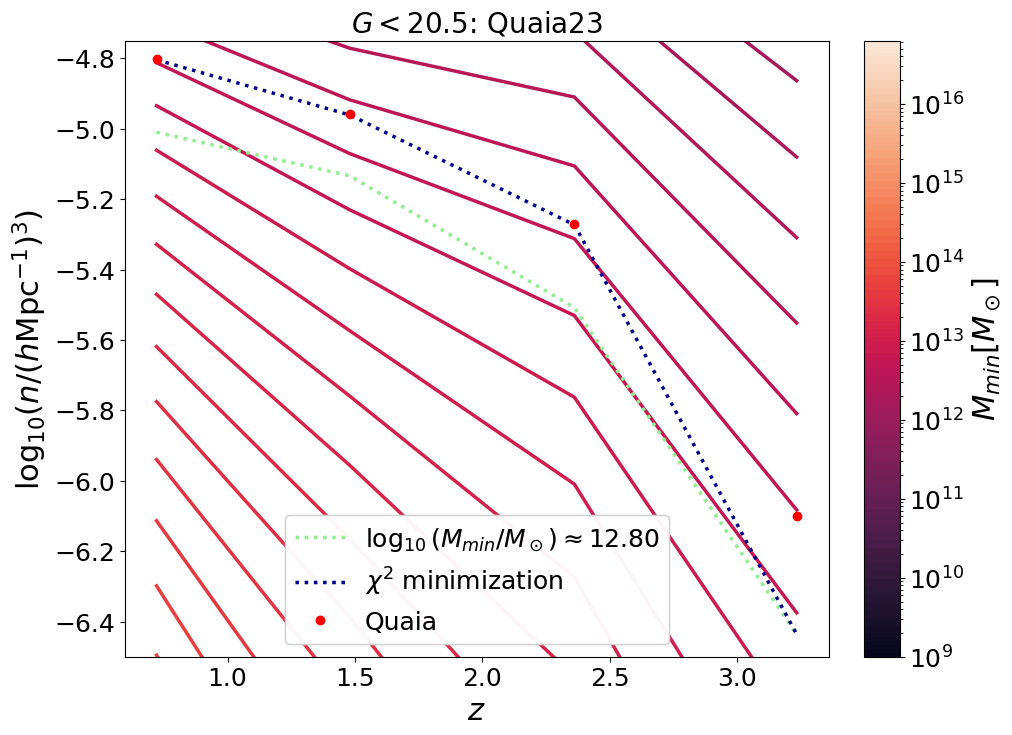

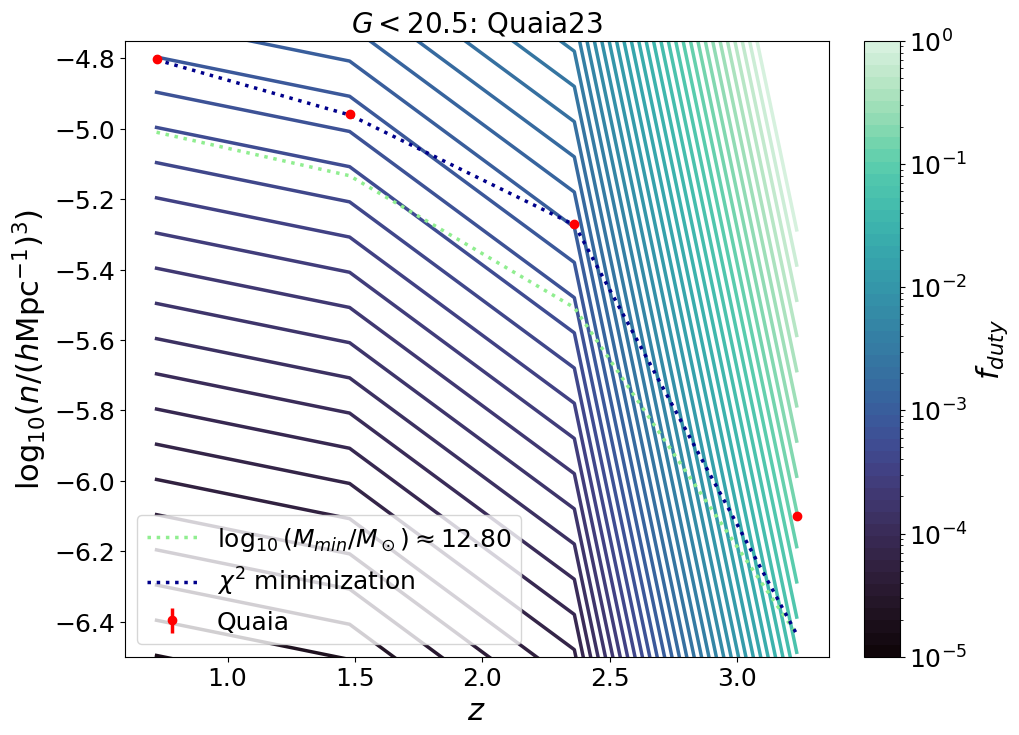

In [101]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
ylim = -6.5, -4.75

for k in range(len(bins)):
    
    n_q_theory = [M(bins_M_min_array[k], n_m_array_2D[j][k], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1] for j in z_array]
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:[{:.2f}-{:.2f}] M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[0]), 
                                                                                                  np.log10(bins[-1])), color = cmap[k])

n_q_theory, n_q_theory_fit = [], []
for j in z_array:
    
    n_q_theory.append(M(bins_M_min[j], n_m_array[j], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1])
    
    n_m=np.ones(np.shape(bins))*fduty_fit[j]
    n_q_theory_fit.append(M(np.logspace(np.log10(M_min_fit[j]), 16.8, 79), n_m, a = a_zbin_b[j], cosmo = cosmos[i], recenter = False)[1])

ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.plot(1/np.array(a_zbin_b)-1, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'$\chi^2$ minimization') 
ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5, 
                       label = r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min)),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5, 
                       label = '$\chi^2$ minimization'), 
                Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia')]
second_legend = ax1.legend(handles = custom_lines)
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
i = 1
l = 38

for k in range(len(fduty_array)):

    n_q_theory=[]
    for j in z_array:
        
        n_m=np.ones(np.shape(bins))*fduty_array[k]
        n_q_theory.append(M(np.logspace(np.log10(M_min_fit[j]), 16.8, 79), n_m, a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1])
        
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             color = cmap_fduty[k])
    
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1] for j in z_array]
ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':', 
         label = r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(np.log10(bins[l]))) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.plot(1/np.array(a_zbin_b)-1, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'$\chi^2$ minimization')

ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)
ax1.legend()

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_fduty, norm = matplotlib.colors.LogNorm(vmin=fduty_array[0], vmax = fduty_array[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$f_{duty}$')
plt.show()